완료한 내용
- received → completed
    - duration 안
    - 시간 순서 고려


추가해야 하는 방식
- received → viewed : 열람률
    - 오퍼가 실제로 고객에게 읽혔는가

- received → completed : 전체 완료율
    - 오퍼를 받은 사람 중 최종적으로 조건 충족까지 간 비율

- viewed → completed : 열람 후 완료율
    - 오퍼를 본 사람 중 실제 행동까지 이어진 비율
    
- received → viewed → completed : 정상 퍼널 완료율
    - received 이후 viewed를 거치고, 그 다음 completed까지 순서대로 간 비율

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import warnings
import platform
import matplotlib.pyplot as plt

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams[
        'font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 사용 함수

In [2]:
# 컬럼 정보 간단 표현
def check_basic_info(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 컬럼 정보 / 결측치 확인 정보 요약")
    print(f"{'='*80}\n")


    # 제외할 컬럼 반영
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # dict, list, set 같은 해시 불가능 값이 들어있는 컬럼은 문자열로 변환
    for col in df_copied.columns:
        try:
            df_copied[col].nunique(dropna=True)
        except TypeError:
            df_copied[col] = df_copied[col].astype(str)
    
    # 1. 전체 요약
    overview_df = pd.DataFrame({
        '항목': ['행 개수', '열 개수', '중복 행 개수'],
        '값': [df_copied.shape[0], df_copied.shape[1], df_copied.duplicated().sum()]
    })
    
    # 2. 컬럼별 요약
    summary_df = pd.DataFrame({
        '데이터타입': df_copied.dtypes.astype(str),
        '행 개수': df_copied.count(),
        '행 비율(%)': (df_copied.count() / len(df) * 100).round(2),
        '결측치 개수': df_copied.isnull().sum(),
        '결측치 비율(%)': (df_copied.isnull().sum() / len(df) * 100).round(2),
        '고유값 개수': df_copied.nunique(dropna=True)
    })
    
    # 3. 보기 좋게 정렬
    summary_df = summary_df.sort_values(
        by=['결측치 개수', '고유값 개수'],
        ascending=[False, False]
    )
    
    print("[전체 요약]")
    display(overview_df)
    
    print("[컬럼별 요약]")
    display(summary_df)

    print("[테이블 요약]")
    display(df.head())

In [3]:
# 컬럼 분포 확인
def check_category_summary(df, df_name, col_name):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 {col_name} 범주 확인")
    print(f"{'='*80}\n")
    
    summary_df = df[col_name].value_counts(dropna=False).reset_index()
    summary_df.columns = [col_name, '개수']
    summary_df['비율(%)'] = (summary_df['개수'] / len(df) * 100).round(2)
    
    display(summary_df.head(10))

# 데이터 로드

In [4]:
# ============================================================
# 1. 원본 데이터 로드
# ============================================================
df = pd.read_csv("data/transcript_portfolio_profile.csv")

# 테이블 복제
# informational은 completed 개념이 없으니 제거하고 시작
# 필요시 그냥 df2 = df.copy() 사용
# df2 = df[df['offer_type'] != 'informational'].copy()
df2 = df.copy()
check_basic_info(df2, 'transcript_portfolio')


transcript_portfolio의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,306137
1,열 개수,20
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
event_reward,float64,33182,10.84,272955,89.16,4
amount,float64,138953,45.39,167184,54.61,5103
offer_id,str,167184,54.61,138953,45.39,10
offer_reward,float64,167184,54.61,138953,45.39,5
difficulty,float64,167184,54.61,138953,45.39,5
duration,float64,167184,54.61,138953,45.39,5
channels,str,167184,54.61,138953,45.39,4
offer_type,str,167184,54.61,138953,45.39,3
web,float64,167184,54.61,138953,45.39,2
mobile,float64,167184,54.61,138953,45.39,2


[테이블 요약]


,customer_id,event,time,offer_id,amount,event_reward,offer_type,offer_reward,difficulty,duration,channels,web,email,mobile,social,gender,age,income,became_member_on,profile_missing
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,bogo,5.0,5.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,F,75.0,100000.0,2017-05-09,1
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,discount,5.0,20.0,10.0,"['web', 'email']",1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,0
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,discount,2.0,10.0,7.0,"['web', 'email', 'mobile']",1.0,1.0,1.0,0.0,M,68.0,70000.0,2018-04-26,1
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,discount,2.0,10.0,10.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,bogo,10.0,10.0,5.0,"['web', 'email', 'mobile', 'social']",1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,0


# 전환율 테이블 생성

전환율 기준 = completed / received\
단, duration 안에서 일어난 completed만 인정

시간 순서를 고려해\
고객 세그먼트, reward, difficulty, channel, offer_type 같은 변수와 붙여 분석

추가적으로
time_completed_rc : received → completed용 completed 시간\
time_completed_vc : viewed → completed용 completed 시간\

플래그 추가 생성
converted_rv : received → viewed\
converted_rc : received → completed\
converted_vc : viewed → completed\
converted_rvc : received → viewed → completed

## received / completed 이벤트 분리
전환율의 분모와 분자 생성

In [5]:
# ============================================================
# received / viewed / completed 이벤트 분리
# ============================================================
# received 분리
received = (
    df2[df2['event'] == 'offer received'][
        [
            'customer_id', 'offer_id', 'time',
            'offer_type', 'offer_reward', 'difficulty', 'duration',
            'web', 'email', 'mobile', 'social'
        ]
    ]
    .copy()
    .rename(columns={'time': 'time_received'})
)

# viewed 분리
viewed = (
    df2[df2['event'] == 'offer viewed'][
        ['customer_id', 'offer_id', 'time']
    ]
    .copy()
    .rename(columns={'time': 'time_viewed'})
)

# completed 분리
completed = (
    df2[df2['event'] == 'offer completed'][
        ['customer_id', 'offer_id', 'time']
    ]
    .copy()
    .rename(columns={'time': 'time_completed'})
)

print("received 행 수:", len(received))
print("viewed 행 수:", len(viewed))
print("completed 행 수:", len(completed))

received 행 수: 76277
viewed 행 수: 57725
completed 행 수: 33182


## 시간순 정렬
customer_id + offer_id 기준으로 시간순 번호를 붙여 맞추기

원래 seq 방식으로 n번째 received와 n번째 completed를 연결하고자 했으나\
같은 고객이 같은 오퍼를 이전 오퍼 유효기간이 끝나기 전에 또 받은 경우 문제가 발생할수도 있어 변경

completed보다 먼저 온 received만 후보로 보고, 그중 가장 최근 received를 연결하는 구조로 변경

코드 실행 시간이 매우 깁니다. (대략 10분)

추가적으로 조건에 맞는 received가 없으면 그냥 넘어갑니다.\
completed는 있었지만 연결 실패한 케이스는 match_df에 저장되지 않습니다.

In [6]:
# ============================================================
# 정렬 + 기준키 생성
# ============================================================
received = received.sort_values(
    ["customer_id", "offer_id", "time_received"]
).reset_index(drop=True)

viewed = viewed.sort_values(
    ["customer_id", "offer_id", "time_viewed"]
).reset_index(drop=True)

completed = completed.sort_values(
    ["customer_id", "offer_id", "time_completed"]
).reset_index(drop=True)

# received 기준 고유 행 번호 만들기
received["received_idx"] = received.index

# 오퍼 유효 종료 시점
received["offer_end_time"] = received["time_received"] + received["duration"] * 24

In [7]:
# ============================================================
# 공통 매칭 함수
# - event를 가장 최근의 유효한 base 이벤트에 연결
# - 시간 순서 맞게
# - duration 안의 이벤트만 인정
# - 1대1방식으로 (한 base는 같은 방식에서 1번만 사용)
# - 매칭 함수
# ============================================================
def match_event_to_base_slow(
        base_df,           # 기준이 되는 이벤트 테이블(received 또는 viewed)
        event_df,          # base에 연결할 이벤트 테이블(viewed 또는 completed)
        base_time_col,     # base 이벤트의 시간 컬럼명
        event_time_col,    # 연결할 event의 시간 컬럼명
        matched_time_col,  # 매칭 후 result에 새로 붙일 시간 컬럼명
        base_id_col="received_idx"  # base 행을 구분하는 고유 식별 컬럼명
        ):
    
    # 매칭 결과를 저장할 리스트
    match_rows = []

    # base 이벤트(received 또는 viewed?) 고객, 오퍼, 시간 순서대로 정렬
    # 후보 선택 시 시간 순서를 안정적으로 보기 위함
    base_sorted = base_df.sort_values(
        ["customer_id", "offer_id", base_time_col]
    ).copy()

    # event 이벤트(viewed 또는 completed) 고객, 오퍼, 시간 순서대로 정렬
    # 이벤트 발생 순서대로 base와 연결
    event_sorted = event_df.sort_values(
        ["customer_id", "offer_id", event_time_col]
    ).copy()

    # event를 customer_id + offer_id 단위로 묶어서 반복
    for (customer_id, offer_id), event_group in event_sorted.groupby(["customer_id", "offer_id"]):
    # 같은 고객이 같은 오퍼에 대해 발생시킨 event끼리만 봄

        # 현재 customer_id + offer_id에 해당하는 base 이벤트들만 따로 추출
        base_group = base_sorted[
            (base_sorted["customer_id"] == customer_id) &
            (base_sorted["offer_id"] == offer_id)
        ].copy()

        # 이미 매칭된 received는 다시 쓰지 않기 위한 집합
        used_base = set()

        # event 발생 시간을 하나씩 확인하면서 조건에 맞는 base 찾기
        for event_time in event_group[event_time_col]:

            # 현재 event_time에 대해 연결 가능한 base 후보 찾기
            candidates = base_group[
                # 조건 1 base 시간이 event 시간보다 같거나 이전
                # 시간 순서상 base가 먼저 발생해야 함
                (base_group[base_time_col] <= event_time) &
                # 조건 2 event가 offer_end_time 이내
                # duration 안에서 일어난 이벤트만 인정
                (event_time <= base_group["offer_end_time"]) &
                # 조건 3 아직 사용되지 않은 base여
                # 같은 received/viewed에 event 여러 개 중복 매칭 방지
                (~base_group[base_id_col].isin(used_base))
            ].copy()

            # 후보가 없으면 다음 completed로
            if len(candidates) == 0:
                continue

            # 후보가 여러 개면 그중 가장 최근의 유효한 base 선택
            best_base = candidates.sort_values(base_time_col, ascending=False).iloc[0]

            # 매칭 결과 저장
            match_rows.append({
                base_id_col: best_base[base_id_col],
                matched_time_col: event_time
            })

            # 사용한 received는 다시 못 쓰게 저장
            used_base.add(best_base[base_id_col])

    # 최종 결과는 base_df를 기준으로 유지
    result = base_df.copy()

    # 매칭 결과가 하나도 없으면 결측치로 만든 뒤 반환
    if len(match_rows) == 0:
        result[matched_time_col] = pd.NA
        return result

    # base_df와 매칭 결과를 base_id_col 기준으로 왼쪽 병합
    match_df = pd.DataFrame(match_rows)

    result = result.merge(
        match_df,
        on=base_id_col,
        how="left"
    )

    return result

In [8]:
# ============================================================
# 공통 매칭 함수
# - event를 가장 최근의 유효한 base 이벤트에 연결
# - 시간 순서 맞게
# - duration 안의 이벤트만 인정
# - 1대1방식으로 (한 base는 같은 방식에서 1번만 사용)
# - 속도 개선 버전
# ============================================================
def match_event_to_base(
        base_df,           # 기준이 되는 이벤트 테이블(received 또는 viewed)
        event_df,          # base에 연결할 이벤트 테이블(viewed 또는 completed)
        base_time_col,     # base 이벤트의 시간 컬럼명
        event_time_col,    # 연결할 event의 시간 컬럼명
        matched_time_col,  # 매칭 후 result에 새로 붙일 시간 컬럼명
        base_id_col="received_idx"  # base 행을 구분하는 고유 식별 컬럼명
        ):
    """
    received 또는 viewed를 기준으로 잡고 그 뒤에 일어난 viewed/completed를
    같은 고객과 같은 오퍼 안에서 가장 최근의 유효한 base에 1대1로 연결
    """
    
    # 매칭 결과를 저장할 리스트
    match_rows = []

    # base 이벤트(received 또는 viewed?) 고객, 오퍼, 시간 순서대로 정렬
    # -> 불필요한 컬럼을 줄여서 속도와 메모리 사용을 줄임
    base_sorted = (
        base_df[["customer_id", "offer_id", base_id_col, base_time_col, "offer_end_time"]]
        .sort_values(["customer_id", "offer_id", base_time_col])
        .reset_index(drop=True)
    )

    # event 이벤트(viewed 또는 completed) 고객, 오퍼, 시간 순서대로 정렬
    # 이벤트 발생 순서대로 base와 연결
    event_sorted = (
        event_df[["customer_id", "offer_id", event_time_col]]
        .sort_values(["customer_id", "offer_id", event_time_col])
        .reset_index(drop=True)
    )

    # base를 customer_id + offer_id 그룹별로 한 번만 저장
    # -> 반복문 안에서 base_group을 계속 다시 찾지 않기 위함
    # -> numpy 배열로 바꿔서 더 빠르게 처리
    base_groups = {
        key: group[[base_id_col, base_time_col, "offer_end_time"]].to_numpy()
        for key, group in base_sorted.groupby(["customer_id", "offer_id"], sort=False)
    }

    # event를 customer_id + offer_id 단위로 묶어서 반복
    for key, event_group in event_sorted.groupby(["customer_id", "offer_id"], sort=False):

        # 현재 그룹에 해당하는 base 가져오기
        bases = base_groups.get(key)

        # 해당 고객+오퍼의 base가 아예 없으면 다음 그룹으로
        if bases is None:
            continue

        # numpy 배열에서 필요한 값 분리
        # base_ids        : base 행의 고유 식별값
        # base_times      : base 발생 시간
        # offer_end_times : 각 base의 유효 종료 시점
        base_ids = bases[:, 0]
        base_times = bases[:, 1].astype(float)
        offer_end_times = bases[:, 2].astype(float)

        # 같은 방식에서 한 base는 1번만 사용
        # -> 이미 사용한 base는 True로 바뀜
        used = np.zeros(len(bases), dtype=bool)

        # event 발생 시간을 하나씩 확인하면서 조건에 맞는 base 찾기
        for event_time in event_group[event_time_col].to_numpy(dtype=float):

            # event_time 이하인 base 중
            # 가장 최근 base 위치를 빠르게 찾음
            # -> searchsorted는 정렬된 배열에서 위치를 빠르게 찾는 함수
            j = np.searchsorted(base_times, event_time, side="right") - 1

            # 가장 최근 후보부터 뒤에서 앞으로 확인
            # -> event와 가장 가까운 이전 base를 선택하기 위함
            while j >= 0:

                # 조건 1 아직 사용되지 않은 base인가?
                # 조건 2 event가 offer_end_time 이내인가?
                # -> duration 안에서 일어난 이벤트만 인정
                if (not used[j]) and (offer_end_times[j] >= event_time):
                    match_rows.append({
                        base_id_col: base_ids[j],
                        matched_time_col: event_time
                    })

                    # 사용한 base는 다시 못 쓰게 저장
                    used[j] = True
                    break

                # 조건이 안 맞으면 더 이전 base를 확인
                j -= 1

    # 최종 결과는 base_df를 기준으로 유지
    result = base_df.copy()

    # 매칭 결과가 하나도 없으면 결측치로 만든 뒤 반환
    if not match_rows:
        result[matched_time_col] = pd.NA
        return result

    # 매칭 결과 리스트를 DataFrame으로 변환
    match_df = pd.DataFrame(match_rows)

    # base_df와 매칭 결과를 base_id_col 기준으로 왼쪽 병합
    # -> 매칭 성공한 행은 시간값이 붙고
    # -> 실패한 행은 NaN으로 남음
    result = result.merge(
        match_df,
        on=base_id_col,
        how="left"
    )

    return result

## 4개 전환 기준 테이블 생성

In [9]:
# ============================================================
# 1) received -> viewed 매칭
# ============================================================
rv = match_event_to_base(
    base_df=received,                 # 기준: 받은 오퍼(received)
    event_df=viewed,                  # 연결 대상: 열람 이벤트(viewed)
    base_time_col="time_received",    # 기준 시간: 오퍼 받은 시점
    event_time_col="time_viewed",     # 연결할 이벤트 시간: 오퍼 본 시점
    matched_time_col="time_viewed"    # 결과로 붙일 컬럼명
)

In [10]:
# ============================================================
# 2) received -> completed 매칭
# ============================================================
rc_match = match_event_to_base(
    base_df=received,                    # 기준: 받은 오퍼(received)
    event_df=completed,                  # 연결 대상: 완료 이벤트(completed)
    base_time_col="time_received",       # 기준 시간: 오퍼 받은 시점
    event_time_col="time_completed",     # 연결할 이벤트 시간: 오퍼 완료 시점
    matched_time_col="time_completed_rc" # 결과로 붙일 컬럼명(received→completed용)
)


In [11]:
# ============================================================
# 3) viewed -> completed 매칭
# viewed가 붙은 received만 대상으로, viewed 이후 completed를 다시 매칭
# ============================================================
view_base = rv[rv["time_viewed"].notna()].copy()

vc_match = match_event_to_base(
    base_df=view_base,                  # 기준: viewed가 확인된 received
    event_df=completed,                 # 연결 대상: 완료 이벤트(completed)
    base_time_col="time_viewed",        # 기준 시간: 오퍼 본 시점
    event_time_col="time_completed",    # 연결할 이벤트 시간: 오퍼 완료 시점
    matched_time_col="time_completed_vc" # 결과로 붙일 컬럼명(viewed→completed용)
)

In [12]:
# ============================================================
# 최종 received 기준 퍼널 테이블 생성
# ============================================================
funnel = received.copy()

# received -> viewed 매칭 결과 붙이기
funnel = funnel.merge(
    rv[["received_idx", "time_viewed"]],
    on="received_idx",
    how="left"
)

# received -> completed 매칭 결과 붙이기
funnel = funnel.merge(
    rc_match[["received_idx", "time_completed_rc"]],
    on="received_idx",
    how="left"
)

# 시간 차이 계산
# 각 단계까지 걸린 시간을 계산
funnel = funnel.merge(
    vc_match[["received_idx", "time_completed_vc"]],
    on="received_idx",
    how="left"
)

# 시간 차이
funnel["rv_time_diff"] = funnel["time_viewed"] - funnel["time_received"]
funnel["rc_time_diff"] = funnel["time_completed_rc"] - funnel["time_received"]
funnel["vc_time_diff"] = funnel["time_completed_vc"] - funnel["time_viewed"]

# 유효 여부 플래그
# 시간값이 존재하면 1, 없으면 0으로 변환
funnel["has_viewed"] = funnel["time_viewed"].notna().astype(int)
funnel["has_completed_rc"] = funnel["time_completed_rc"].notna().astype(int)
funnel["has_completed_after_view"] = funnel["time_completed_vc"].notna().astype(int)

# 전환 플래그
# converted_rv  : received -> viewed 전환 여부
funnel["converted_rv"] = funnel["has_viewed"]

# converted_rc  : received -> completed 전환 여부
funnel["converted_rc"] = funnel["has_completed_rc"]

# converted_vc  : viewed -> completed 전환 여부
funnel["converted_vc"] = funnel["has_completed_after_view"]

# converted_rvc : received -> viewed -> completed 전환 여부
funnel["converted_rvc"] = (
    (funnel["has_viewed"] == 1) &
    (funnel["has_completed_after_view"] == 1)
).astype(int)

# 기존 코드 호환용
# 기존 converted_final 의미를 유지하려면 received -> completed로 둠
funnel["converted_final"] = funnel["converted_rc"]

In [13]:
# ------------------------------------------------------------
# 퍼널 분석에 필요한 핵심 컬럼만 선택해서 최종 테이블 형태로 정리
# ------------------------------------------------------------
funnel = funnel[
    [
        'customer_id', 'offer_id',                          # 고객 / 오퍼 식별 정보
        'offer_type', 'offer_reward', 'difficulty', 'duration',   # 오퍼 속성 정보
        'web', 'email', 'mobile', 'social',                # 오퍼 발송 채널 정보

        'time_received', 'offer_end_time',                 # 오퍼 수신 시점 / 오퍼 유효 종료 시점
        'time_viewed', 'time_completed_rc', 'time_completed_vc',   # 단계별 매칭 시간 정보

        'rv_time_diff', 'rc_time_diff', 'vc_time_diff',    # 단계별 소요 시간 정보

        'has_viewed', 'has_completed_rc', 'has_completed_after_view',  # 이벤트 연결 여부 플래그

        'converted_rv', 'converted_rc', 'converted_vc', 'converted_rvc', # 전환 여부 플래그
        'converted_final'                                  # 기존 코드 호환용 최종 전환 컬럼
    ]
].copy()

# ------------------------------------------------------------
# 최종 funnel 테이블의 기본 정보(행/열 수, 결측치, 타입 등) 확인
# ------------------------------------------------------------
check_basic_info(funnel, 'received 기준 funnel 테이블')


received 기준 funnel 테이블의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,76277
1,열 개수,26
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
time_completed_vc,float64,23496,30.80,52781,69.20,120
vc_time_diff,float64,23496,30.80,52781,69.20,41
time_completed_rc,float64,33152,43.46,43125,56.54,120
rc_time_diff,float64,33152,43.46,43125,56.54,41
time_viewed,float64,56567,74.16,19710,25.84,120
rv_time_diff,float64,56567,74.16,19710,25.84,41
customer_id,str,76277,100.00,0,0.00,16994
offer_end_time,float64,76277,100.00,0,0.00,22
offer_id,str,76277,100.00,0,0.00,10
time_received,int64,76277,100.00,0,0.00,6


[테이블 요약]


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,offer_end_time,time_viewed,time_completed_rc,time_completed_vc,rv_time_diff,rc_time_diff,vc_time_diff,has_viewed,has_completed_rc,has_completed_after_view,converted_rv,converted_rc,converted_vc,converted_rvc,converted_final
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,744.0,NaN,576.0,NaN,NaN,0.0,NaN,0,1,0,0,1,0,0,1
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,0.0,0.0,4.0,1.0,1.0,1.0,0.0,336,432.0,372.0,NaN,NaN,36.0,NaN,NaN,1,0,0,1,0,0,0,0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,0.0,0.0,3.0,0.0,1.0,1.0,1.0,168,240.0,192.0,NaN,NaN,24.0,NaN,NaN,1,0,0,1,0,0,0,0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,528.0,456.0,414.0,NaN,48.0,6.0,NaN,1,1,0,1,1,0,0,1
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,744.0,540.0,528.0,NaN,36.0,24.0,NaN,1,1,0,1,1,0,0,1


## 완성물 해설

- customer_id               : 고객 식별 ID
- offer_id                  : 오퍼 식별 ID

- offer_type                : 오퍼 유형(bogo, discount, informational 등)
- offer_reward              : 오퍼 보상값
- difficulty                : 오퍼 완료 조건 금액/난이도
- duration                  : 오퍼 유효기간(일 단위)

- web                       : 웹 채널 발송 여부
- email                     : 이메일 채널 발송 여부
- mobile                    : 모바일 채널 발송 여부
- social                    : 소셜 채널 발송 여부

- time_received             : 오퍼를 받은 시점
- offer_end_time            : 오퍼 유효 종료 시점(time_received + duration*24)
- time_viewed               : received 이후 매칭된 viewed 시점
- time_completed_rc         : received 이후 매칭된 completed 시점
- time_completed_vc         : viewed 이후 매칭된 completed 시점

- rv_time_diff              : received 후 viewed까지 걸린 시간
- rc_time_diff              : received 후 completed까지 걸린 시간
- vc_time_diff              : viewed 후 completed까지 걸린 시간

- has_viewed                : viewed 매칭 여부(있으면 1, 없으면 0)
- has_completed_rc          : received 기준 completed 매칭 여부(있으면 1, 없으면 0)
- has_completed_after_view  : viewed 기준 completed 매칭 여부(있으면 1, 없으면 0)

- converted_rv              : received -> viewed 전환 여부 : 열람률
- converted_rc              : received -> completed 전환 여부 : 전체 완료율
- converted_vc              : viewed -> completed 전환 여부 : 열람 후 완료율
- converted_rvc             : received -> viewed -> completed 전환 여부 : 정상 퍼널 완료율

- converted_final           : 기존 코드 호환용 최종 전환 컬럼(received -> completed 기준)


In [14]:
# 오퍼 반응 퍼널 분석에 필요한 핵심 컬럼만 선별
# 식별자, 오퍼 속성, 채널, 기준 시점, 시간차, 전환 여부 중심으로 구성
funnel_clean = funnel[
    [
        'customer_id',      # 고객 식별 ID
        'offer_id',         # 오퍼 식별 ID

        'offer_type',       # 오퍼 유형(bogo, discount, informational 등)
        'offer_reward',     # 오퍼 보상값
        'difficulty',       # 오퍼 완료 조건 금액/난이도
        'duration',         # 오퍼 유효기간(일 단위)

        'web',              # 웹 채널 발송 여부
        'email',            # 이메일 채널 발송 여부
        'mobile',           # 모바일 채널 발송 여부
        'social',           # 소셜 채널 발송 여부

        'time_received',    # 오퍼를 받은 시점
        'offer_end_time',   # 오퍼 유효 종료 시점(time_received + duration*24)

        'rv_time_diff',     # received 후 viewed까지 걸린 시간
        'rc_time_diff',     # received 후 completed까지 걸린 시간
        'vc_time_diff',     # viewed 후 completed까지 걸린 시간

        'converted_rv',     # received -> viewed 전환 여부
        'converted_rc',     # received -> completed 전환 여부
        'converted_vc',     # viewed -> completed 전환 여부
        'converted_rvc'     # received -> viewed -> completed 전환 여부
    ]
].copy()

# converted_final
# 기존 코드 호환용 컬럼으로, converted_rc와 의미가 겹쳐 제외

# has_viewed, has_completed_rc, has_completed_after_view
# 매칭 여부 컬럼이지만 rv, rc, vc가  더 직관적으로 보여주므로 제외

# time_viewed, time_completed_rc, time_completed_vc
# 상세 시점 확인용 컬럼

# 고객 세그먼트 변수(age, gender, income, became_member_on)는 추후 필요 시 merge

check_basic_info(funnel_clean, ' funnel_clean 테이블')


 funnel_clean 테이블의 컬럼 정보 / 결측치 확인 정보 요약

[전체 요약]


,항목,값
0,행 개수,76277
1,열 개수,19
2,중복 행 개수,0


[컬럼별 요약]


,데이터타입,행 개수,행 비율(%),결측치 개수,결측치 비율(%),고유값 개수
vc_time_diff,float64,23496,30.80,52781,69.20,41
rc_time_diff,float64,33152,43.46,43125,56.54,41
rv_time_diff,float64,56567,74.16,19710,25.84,41
customer_id,str,76277,100.00,0,0.00,16994
offer_end_time,float64,76277,100.00,0,0.00,22
offer_id,str,76277,100.00,0,0.00,10
time_received,int64,76277,100.00,0,0.00,6
offer_reward,float64,76277,100.00,0,0.00,5
difficulty,float64,76277,100.00,0,0.00,5
duration,float64,76277,100.00,0,0.00,5


[테이블 요약]


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,offer_end_time,rv_time_diff,rc_time_diff,vc_time_diff,converted_rv,converted_rc,converted_vc,converted_rvc
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,744.0,NaN,0.0,NaN,0,1,0,0
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,0.0,0.0,4.0,1.0,1.0,1.0,0.0,336,432.0,36.0,NaN,NaN,1,0,0,0
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,0.0,0.0,3.0,0.0,1.0,1.0,1.0,168,240.0,24.0,NaN,NaN,1,0,0,0
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,528.0,48.0,6.0,NaN,1,1,0,0
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,744.0,36.0,24.0,NaN,1,1,0,0


## 검증단계

In [15]:
print("=" * 80)
print("기본 검증단계")
print("=" * 80)

received_count = len(funnel_clean)
viewed_count = funnel_clean["converted_rv"].sum()
completed_rc_count = funnel_clean["converted_rc"].sum()
completed_vc_count = funnel_clean["converted_vc"].sum()
strict_funnel_count = funnel_clean["converted_rvc"].sum()

rv_rate = viewed_count / received_count * 100 if received_count > 0 else 0
rc_rate = completed_rc_count / received_count * 100 if received_count > 0 else 0
vc_rate = completed_vc_count / viewed_count * 100 if viewed_count > 0 else 0
rvc_rate = strict_funnel_count / received_count * 100 if received_count > 0 else 0

print("received 기준 전체 건수:", received_count)
print("viewed가 붙은 건수:", viewed_count)
print("completed(received 기준)가 붙은 건수:", completed_rc_count)
print("completed(viewed 기준)가 붙은 건수:", completed_vc_count)
print("strict funnel 완료 건수:", strict_funnel_count)
print()

print("received → viewed 전환율:", round(rv_rate, 2), "%")
print("received → completed 전환율:", round(rc_rate, 2), "%")
print("viewed → completed 전환율:", round(vc_rate, 2), "%")
print("received → viewed → completed 전환율:", round(rvc_rate, 2), "%")

기본 검증단계
received 기준 전체 건수: 76277
viewed가 붙은 건수: 56567
completed(received 기준)가 붙은 건수: 33152
completed(viewed 기준)가 붙은 건수: 23496
strict funnel 완료 건수: 23496

received → viewed 전환율: 74.16 %
received → completed 전환율: 43.46 %
viewed → completed 전환율: 41.54 %
received → viewed → completed 전환율: 30.8 %


# 주의 

구매 전환율이 아니라 오퍼 유효 완료 전환율임


분석할 내용들

1. 어떤 고객 세그먼트가 어떤 프로모션에 더 잘 반응하는가(열람)?
2. 어떤 채널 조합에서 오퍼 반응률이 더 높은가?
3. 어떤 고객군이 오퍼를 본 뒤 완료까지 더 잘 이어지는가?
4. 어떤 프로모션 유형이 열람률·완료율 측면에서 더 성과가 좋은가?
5. 이 결과를 마케팅 실무자가 빠르게 해석할 수 있도록 Tableau 대시보드로 구현한다.

# 1. 어떤 고객 세그먼트가 어떤 프로모션에 더 잘 반응하는가(열람)?
고객 특성에 따라 어떤 프로모션 유형에 더 잘 반응하는가?

- 고객 세그먼트 종류
    - gender
    - age
    - income
    - became_member_on

- 사용 지표
    - `converted_rv` : 오퍼를 받은 뒤 실제로 열람했는가
    - `converted_rc` : 오퍼를 받은 뒤 완료했는가
    - `converted_rvc` : 오퍼를 받고, 열람 후, 완료까지 이어졌는가


## 1. 고객 세그먼트 컬럼 생성

In [16]:
# 1. 고객 세그먼트 정보 준비

# 고객 기준 프로필 정보만 추출
profile_base = (
    df2[[
        'customer_id', 
        'gender',
        'age', 
        'income', 
        'became_member_on']]
    .drop_duplicates(subset=['customer_id'])
    .copy()
)
print("profile_base 고객 수:", profile_base['customer_id'].nunique())

# funnel_clean에 고객 세그먼트 정보 붙이기
funnel_seg = funnel_clean.merge(
    profile_base,
    on='customer_id',
    how='left'
)

print("funnel_seg 행 수:", len(funnel_seg))
print("funnel_seg 고객 수:", funnel_seg['customer_id'].nunique())
display(funnel_seg.head())

profile_base 고객 수: 17000
funnel_seg 행 수: 76277
funnel_seg 고객 수: 16994


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,offer_end_time,rv_time_diff,rc_time_diff,vc_time_diff,converted_rv,converted_rc,converted_vc,converted_rvc,gender,age,income,became_member_on
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount,2.0,10.0,7.0,1.0,1.0,1.0,0.0,576,744.0,NaN,0.0,NaN,0,1,0,0,M,33.0,72000.0,2017-04-21
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational,0.0,0.0,4.0,1.0,1.0,1.0,0.0,336,432.0,36.0,NaN,NaN,1,0,0,0,M,33.0,72000.0,2017-04-21
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational,0.0,0.0,3.0,0.0,1.0,1.0,1.0,168,240.0,24.0,NaN,NaN,1,0,0,0,M,33.0,72000.0,2017-04-21
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,528.0,48.0,6.0,NaN,1,1,0,0,M,33.0,72000.0,2017-04-21
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,744.0,36.0,24.0,NaN,1,1,0,0,M,33.0,72000.0,2017-04-21


In [17]:
# ============================================================
# profile 전체 고객과 funnel 기준 고객 비교
# ============================================================

all_profile_customers = set(profile_base['customer_id'])
funnel_customers = set(funnel_clean['customer_id'])

missing_customers = sorted(all_profile_customers - funnel_customers)

print("profile 전체 고객 수:", len(all_profile_customers))
print("funnel 고객 수:", len(funnel_customers))
print("빠진 고객 수:", len(missing_customers))

# 빠진 고객들의 transcript 이벤트 확인
missing_event_check = (
    df2[df2['customer_id'].isin(missing_customers)]
    .groupby(['customer_id', 'event'])
    .size()
    .reset_index(name='count')
    .sort_values(['customer_id', 'event'])
)

display(missing_event_check)

profile 전체 고객 수: 17000
funnel 고객 수: 16994
빠진 고객 수: 6


,customer_id,event,count
0,12ede229379747bd8d74ccdc20097ca3,transaction,3
1,3a4874d8f0ef42b9a1b72294902afea9,transaction,3
2,ae8111e7e8cd4b60a8d35c42c1110555,transaction,5
3,c6e579c6821c41d1a7a6a9cf936e91bb,transaction,4
4,da7a7c0dcfcb41a8acc7864a53cf60fb,transaction,1
5,eb540099db834cf59001f83a4561aef3,transaction,4


고객수가 6명 빠진 이유?
- profile에는 있는데 received 기준 퍼널(funnel_clean)에는 한 번도 들어오지 않은 고객
- 즉, 전체 고객 17,000명 중 6명은 아예 offer received 이벤트가 없었다

## 2. 세그먼트 그룹핑

1. gender_group
    - F
    - M
    - O
    - Missing

2. age_group
    - 18-29
    - 30-39
    - 40-49
    - 50-59
    - 60-69
    - 70+
    - Missing

3. income_group
    - 30k-49k
    - 50k-69k
    - 70k-89k
    - 90k+
    - Missing

4. member_cohort
    - 2013~2014
    - 2015~2016
    - 2017~2018
    - Missing

In [18]:
funnel_seg = funnel_seg.copy()

# ======================================================================================
# 1. gender_group
funnel_seg['gender_group'] = (
    funnel_seg['gender']
    .fillna('Missing')
)
# ======================================================================================

# ======================================================================================
# 2. age_group
funnel_seg['age_clean'] = (
    funnel_seg['age']
    .where(
        funnel_seg['age']
        .between(18, 100),pd.NA)
)

funnel_seg['age_group'] = pd.cut(
    funnel_seg['age_clean'],
    bins=[18, 30, 40, 50, 60, 70, float('inf')],
    right=False,
    labels=['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
)

funnel_seg['age_group'] = funnel_seg['age_group'].astype('object').fillna('Missing')
# ======================================================================================

# ======================================================================================
# 3. income_group
funnel_seg['income_group'] = pd.cut(
    funnel_seg['income'],
    bins=[30000, 50000, 70000, 90000, float('inf')],
    right=False,
    labels=['30k-49k', '50k-69k', '70k-89k', '90k+']
)

funnel_seg['income_group'] = funnel_seg['income_group'].astype('object').fillna('Missing')
# ======================================================================================

# ======================================================================================
# 4. member_cohort
funnel_seg['became_member_on'] = funnel_seg['became_member_on'].astype('string')
funnel_seg['member_year'] = pd.to_numeric(
    funnel_seg['became_member_on'].str[:4],
    errors='coerce'
)

funnel_seg['member_cohort'] = pd.cut(
    funnel_seg['member_year'],
    bins=[2013, 2015, 2017, 2019],
    right=False,
    labels=['2013-2014', '2015-2016', '2017-2018']
)

funnel_seg['member_cohort'] = funnel_seg['member_cohort'].astype('object').fillna('Missing')
# ======================================================================================

# 최종확인
display(
    funnel_seg[
        [
            'customer_id', 'gender', 'gender_group',
            'age', 'age_group',
            'income', 'income_group',
            'became_member_on', 'member_year', 'member_cohort'
        ]
    ].head(10)
)

,customer_id,gender,gender_group,age,age_group,income,income_group,became_member_on,member_year,member_cohort
0,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
1,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
2,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
3,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
4,0009655768c64bdeb2e877511632db8f,M,M,33.0,30-39,72000.0,70k-89k,2017-04-21,2017,2017-2018
5,00116118485d4dfda04fdbaba9a87b5c,NaN,Missing,NaN,Missing,NaN,Missing,<NA>,<NA>,Missing
6,00116118485d4dfda04fdbaba9a87b5c,NaN,Missing,NaN,Missing,NaN,Missing,<NA>,<NA>,Missing
7,0011e0d4e6b944f998e987f904e8c1e5,O,O,40.0,40-49,57000.0,50k-69k,2018-01-09,2018,2017-2018
8,0011e0d4e6b944f998e987f904e8c1e5,O,O,40.0,40-49,57000.0,50k-69k,2018-01-09,2018,2017-2018
9,0011e0d4e6b944f998e987f904e8c1e5,O,O,40.0,40-49,57000.0,50k-69k,2018-01-09,2018,2017-2018


## 3. 세그멘트별 기본 분포 확인

In [19]:
# ============================================================
# 세그먼트별 기본 분포 확인
# ============================================================
check_category_summary(funnel_seg, "funnel_seg", 'gender_group')
check_category_summary(funnel_seg, "funnel_seg", 'age_group')
check_category_summary(funnel_seg, "funnel_seg", 'income_group')
check_category_summary(funnel_seg, "funnel_seg", 'member_cohort')



funnel_seg의 gender_group 범주 확인



,gender_group,개수,비율(%)
0,M,38129,49.99
1,F,27456,36.00
2,Missing,9776,12.82
3,O,916,1.20



funnel_seg의 age_group 범주 확인



,age_group,개수,비율(%)
0,50-59,15894,20.84
1,60-69,13423,17.60
2,70+,12885,16.89
3,40-49,10288,13.49
4,Missing,9799,12.85
5,18-29,7095,9.30
6,30-39,6893,9.04



funnel_seg의 income_group 범주 확인



,income_group,개수,비율(%)
0,50k-69k,22428,29.40
1,30k-49k,16967,22.24
2,70k-89k,16783,22.00
3,90k+,10323,13.53
4,Missing,9776,12.82



funnel_seg의 member_cohort 범주 확인



,member_cohort,개수,비율(%)
0,2017-2018,41632,54.58
1,2015-2016,20670,27.10
2,Missing,9776,12.82
3,2013-2014,4199,5.50


## 4. 세그먼트 × 프로모션 유형 반응률 요약표

In [20]:
# ============================================================
# 세그먼트 × offer_type 반응률 요약 함수
# ============================================================
def make_segment_offer_rv_summary(df, segment_col):
    summary = (
        df.groupby([segment_col, 'offer_type'], dropna=False)
        .agg(
            received_cnt=('customer_id', 'size'),
            viewed_cnt=('converted_rv', 'sum')
        )
        .reset_index()
    )

    summary['rv_rate'] = summary['viewed_cnt'] / summary['received_cnt'] * 100

    return summary

In [21]:
gender_offer_rv_summary = make_segment_offer_rv_summary(funnel_seg, 'gender_group')
age_offer_rv_summary = make_segment_offer_rv_summary(funnel_seg, 'age_group')
income_offer_rv_summary = make_segment_offer_rv_summary(funnel_seg, 'income_group')
cohort_offer_rv_summary = make_segment_offer_rv_summary(funnel_seg, 'member_cohort')

In [22]:
print("=" * 70)
print("gender × offer_type")
print("=" * 70)
display(gender_offer_rv_summary.head(5))

print("=" * 70)
print("age_group × offer_type")
print("=" * 70)
display(age_offer_rv_summary.head(5))

print("=" * 70)
print("income_group × offer_type")
print("=" * 70)
display(income_offer_rv_summary.head(5))

print("=" * 70)
print("member_cohort × offer_type")
print("=" * 70)
display(cohort_offer_rv_summary.head(5))

gender × offer_type


,gender_group,offer_type,received_cnt,viewed_cnt,rv_rate
0,F,bogo,10975,9065,82.596811
1,F,discount,10943,7700,70.364617
2,F,informational,5538,3530,63.741423
3,M,bogo,15208,12485,82.094950
4,M,discount,15354,10396,67.708740


age_group × offer_type


,age_group,offer_type,received_cnt,viewed_cnt,rv_rate
0,18-29,bogo,2831,2298,81.172730
1,18-29,discount,2888,1708,59.141274
2,18-29,informational,1376,823,59.811047
3,30-39,bogo,2710,2202,81.254613
4,30-39,discount,2805,1811,64.563280


income_group × offer_type


,income_group,offer_type,received_cnt,viewed_cnt,rv_rate
0,30k-49k,bogo,6781,5379,79.324583
1,30k-49k,discount,6837,4012,58.680708
2,30k-49k,informational,3349,1977,59.032547
3,50k-69k,bogo,8886,7576,85.257709
4,50k-69k,discount,8965,6511,72.626882


member_cohort × offer_type


,member_cohort,offer_type,received_cnt,viewed_cnt,rv_rate
0,2013-2014,bogo,1667,1388,83.263347
1,2013-2014,discount,1686,1162,68.920522
2,2013-2014,informational,846,547,64.657210
3,2015-2016,bogo,8260,6837,82.772397
4,2015-2016,discount,8295,5822,70.186860


## 5. 세그먼트별 전체 반응률 요약표

In [23]:
# ============================================================
# 세그먼트별 전체 반응률 요약
# ============================================================
def make_segment_rv_summary(df, segment_col):
    summary = (
        df.groupby(segment_col, dropna=False)
        .agg(
            received_cnt=('customer_id', 'size'),
            viewed_cnt=('converted_rv', 'sum')
        )
        .reset_index()
    )

    summary['rv_rate'] = summary['viewed_cnt'] / summary['received_cnt'] * 100
    summary['segment_share'] = summary['received_cnt'] / summary['received_cnt'].sum() * 100

    return summary

In [24]:
# ============================================================
# 7. 세그먼트별 전체 반응률 확인
# ============================================================
gender_rv_summary = make_segment_rv_summary(funnel_seg, 'gender_group')
age_rv_summary = make_segment_rv_summary(funnel_seg, 'age_group')
income_rv_summary = make_segment_rv_summary(funnel_seg, 'income_group')
cohort_rv_summary = make_segment_rv_summary(funnel_seg, 'member_cohort')

In [25]:
print("=" * 70)
print("gender 전체 반응률")
print("=" * 70)
display(gender_rv_summary)

print("=" * 70)
print("age_group 전체 반응률")
print("=" * 70)
display(age_rv_summary)

print("=" * 70)
print("income_group 전체 반응률")
print("=" * 70)
display(income_rv_summary)

print("=" * 70)
print("member_cohort 전체 반응률")
print("=" * 70)
display(cohort_rv_summary)

gender 전체 반응률


,gender_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,F,27456,20295,73.918269,35.995123
1,M,38129,27779,72.855307,49.987545
2,Missing,9776,7724,79.009820,12.816445
3,O,916,769,83.951965,1.200886


age_group 전체 반응률


,age_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,18-29,7095,4829,68.062016,9.301624
1,30-39,6893,4888,70.912520,9.036800
2,40-49,10288,7993,77.692457,13.487683
3,50-59,15894,11748,73.914685,20.837212
4,60-69,13423,9931,73.984951,17.597703
5,70+,12885,9438,73.247963,16.892379
6,Missing,9799,7740,78.987652,12.846599


income_group 전체 반응률


,income_group,received_cnt,viewed_cnt,rv_rate,segment_share
0,30k-49k,16967,11368,67.000648,22.243927
1,50k-69k,22428,17313,77.193686,29.403359
2,70k-89k,16783,12752,75.981648,22.002701
3,90k+,10323,7410,71.781459,13.533568
4,Missing,9776,7724,79.009820,12.816445


member_cohort 전체 반응률


,member_cohort,received_cnt,viewed_cnt,rv_rate,segment_share
0,2013-2014,4199,3097,73.755656,5.504936
1,2015-2016,20670,15366,74.339623,27.098601
2,2017-2018,41632,30380,72.972713,54.580018
3,Missing,9776,7724,79.009820,12.816445


## 6. 시각화

### 그래프 함수

In [26]:
import seaborn as sns

segment_order_map = {
    'gender_group': ['F', 'M', 'O', 'Missing'],
    'age_group': ['18-29', '30-39', '40-49', '50-59', '60-69', '70+', 'Missing'],
    'income_group': ['30k-49k', '50k-69k', '70k-89k', '90k+', 'Missing'],
    'member_cohort': ['2013-2014', '2015-2016', '2017-2018', 'Missing']
}


In [27]:
# 세그먼트 × 프로모션 유형 열람률 막대그래프 함수
def plot_segment_offer_rv(summary_df, segment_col, group_title):

    df_a = summary_df.copy()

    if segment_col in segment_order_map:
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )

    offer_order = ['bogo', 'discount', 'informational']
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )

    df_a = df_a.sort_values(['offer_type', segment_col])

    offer_types = [x for x in offer_order if x in df_a['offer_type'].dropna().unique()]
    n_rows = len(offer_types)

    fig, axes = plt.subplots(n_rows, 1, figsize=(10, n_rows * 4))

    if n_rows == 1:
        axes = [axes]

    for i, offer in enumerate(offer_types):
        temp_df = df_a[df_a['offer_type'] == offer].copy()

        sns.barplot(
            data=temp_df,
            x=segment_col,
            y='rv_rate',
            ax=axes[i]
        )

        axes[i].set_title(f"{offer} - 열람률", fontsize=12, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("rv_rate (%)")
        axes[i].grid(axis='y', linestyle='--', alpha=0.3)

        for p in axes[i].patches:
            height = p.get_height()
            if pd.notna(height):
                axes[i].annotate(
                    f"{height:.1f}",
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    xytext=(0, 3),
                    textcoords='offset points'
                )

    fig.suptitle(f"[{group_title}] 세그먼트 × 프로모션 유형 열람률", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [28]:
# 세그먼트별 전체 열람률 막대그래프 함수
def plot_segment_rv_summary(summary_df, segment_col, group_title):

    df_a = summary_df.copy()

    if segment_col in segment_order_map:
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )
        df_a = df_a.sort_values(segment_col)

    fig, ax = plt.subplots(figsize=(10, 5))

    sns.barplot(
        data=df_a,
        x=segment_col,
        y='rv_rate',
        ax=ax
    )

    ax.set_title(f"[{group_title}] 열람률 비교", fontsize=13, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("rv_rate (%)")
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    for p in ax.patches:
        height = p.get_height()
        if pd.notna(height):
            ax.annotate(
                f"{height:.1f}",
                (p.get_x() + p.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=9,
                xytext=(0, 3),
                textcoords='offset points'
            )

    plt.tight_layout()
    plt.show()

In [29]:
# 세그먼트 × 오퍼 유형 히트맵 함수
def plot_segment_offer_heatmap(summary_df, segment_col, rate_col, group_title):
    
    # 데이터 복사
    df_a = summary_df.copy()
    
    # 세그먼트 순서 정렬
    if segment_col in segment_order_map:
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )
    
    # offer_type 순서 정렬
    offer_order = ['bogo', 'discount', 'informational']
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )
    
    df_a = df_a.sort_values([segment_col, 'offer_type'])
    
    # 지표명 한글 변환
    rate_name_map = {
        'rv_rate': '열람률',
        'rc_rate': '완료율',
        'rvc_rate': '정상 퍼널 완료율'
    }
    rate_name = rate_name_map.get(rate_col, rate_col)
    
    # 피벗 테이블 생성
    pivot_df = df_a.pivot(
        index=segment_col,
        columns='offer_type',
        values=rate_col
    )
    
    # 그래프
    fig, ax = plt.subplots(figsize=(8, max(4, len(pivot_df) * 0.7)))
    im = ax.imshow(pivot_df, aspect='auto')
    
    # 축 설정
    ax.set_xticks(range(len(pivot_df.columns)))
    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticks(range(len(pivot_df.index)))
    ax.set_yticklabels(pivot_df.index)
    
    # 셀 안 수치 표시
    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            value = pivot_df.iloc[i, j]
            if pd.notna(value):
                ax.text(
                    j, i,
                    f"{value:.1f}",
                    ha='center',
                    va='center',
                    fontsize=9
                )
    
    plt.title(f"[{group_title}] 세그먼트 × 오퍼 유형 {rate_name} 히트맵")
    plt.xlabel("offer_type")
    plt.ylabel(segment_col)
    plt.colorbar(im, ax=ax, label='반응률(%)')
    plt.tight_layout()
    plt.show()
    
    return df_a

### 그래프 사용

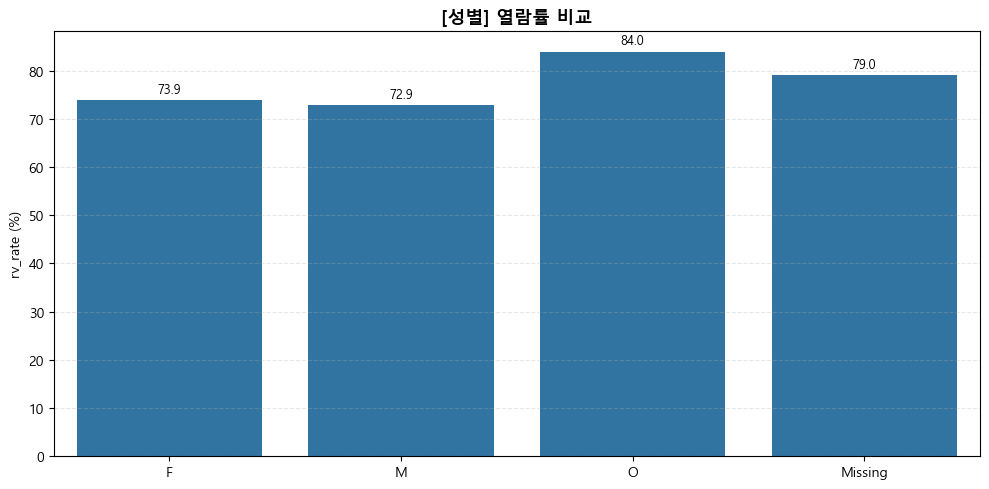

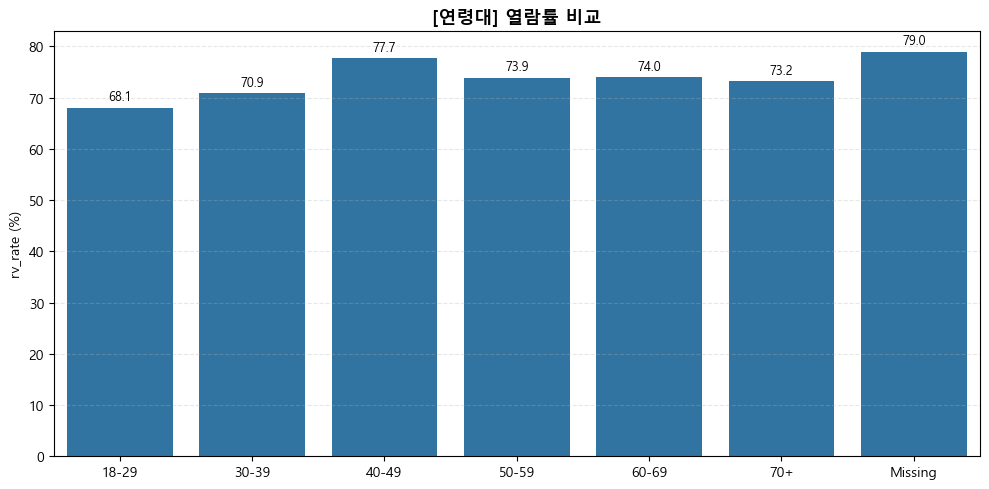

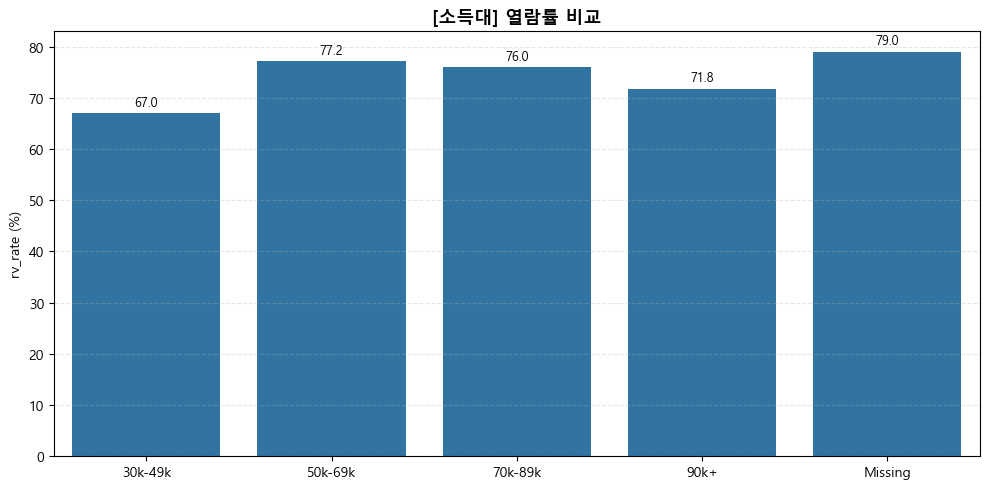

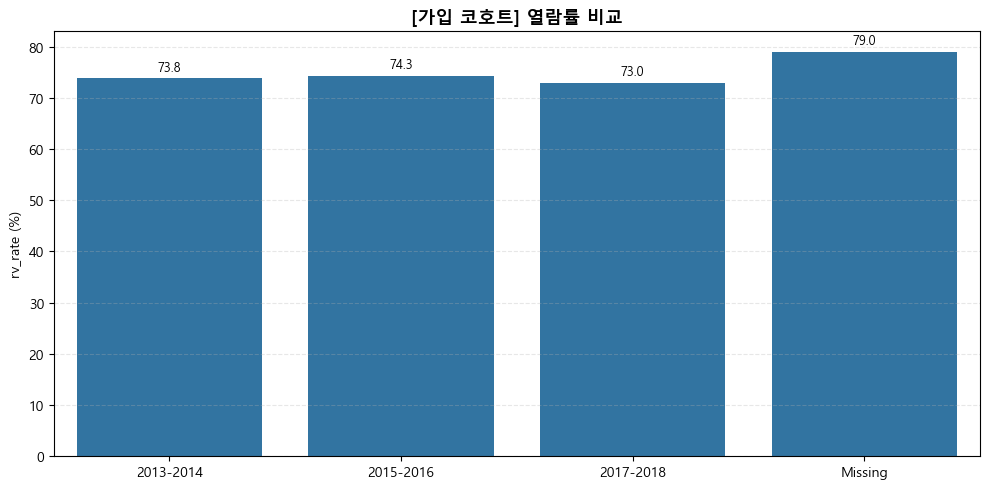

In [30]:
# ============================================================
# 세그먼트별 전체 열람률
# ============================================================
plot_segment_rv_summary(gender_rv_summary, 'gender_group', '성별')
plot_segment_rv_summary(age_rv_summary, 'age_group', '연령대')
plot_segment_rv_summary(income_rv_summary, 'income_group', '소득대')
plot_segment_rv_summary(cohort_rv_summary, 'member_cohort', '가입 코호트')


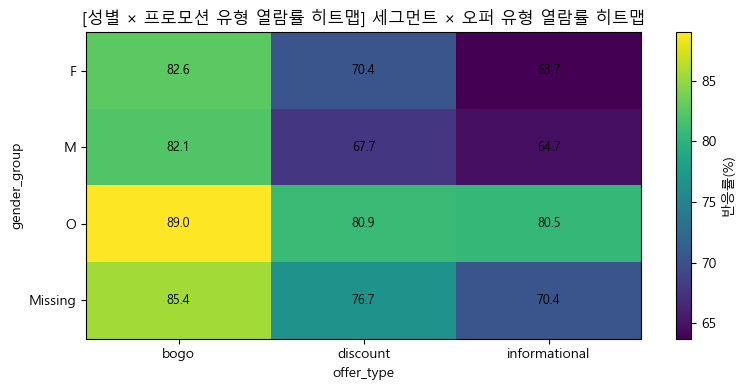

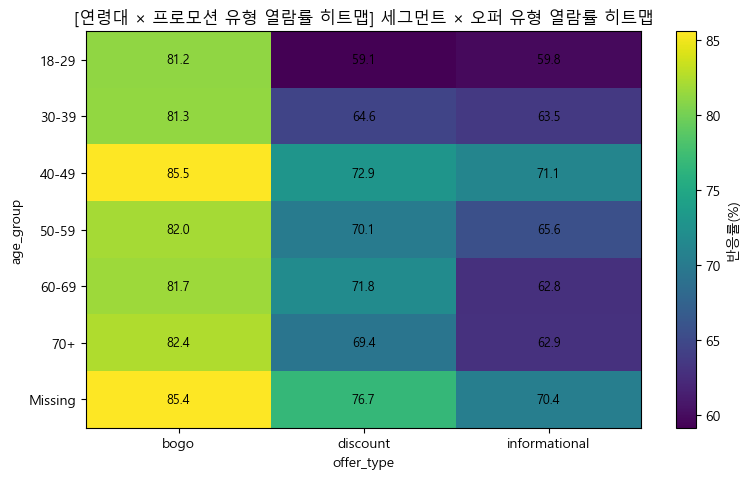

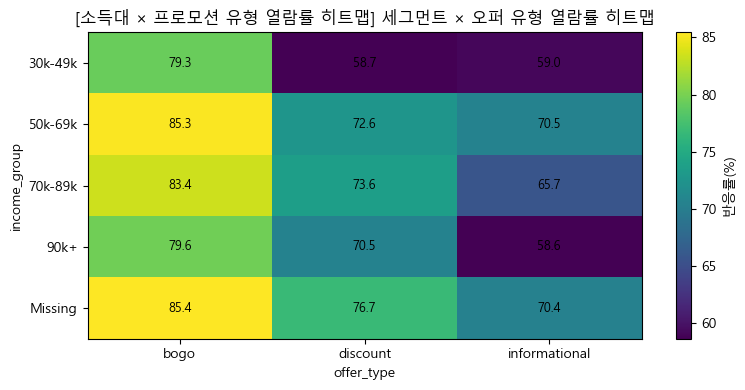

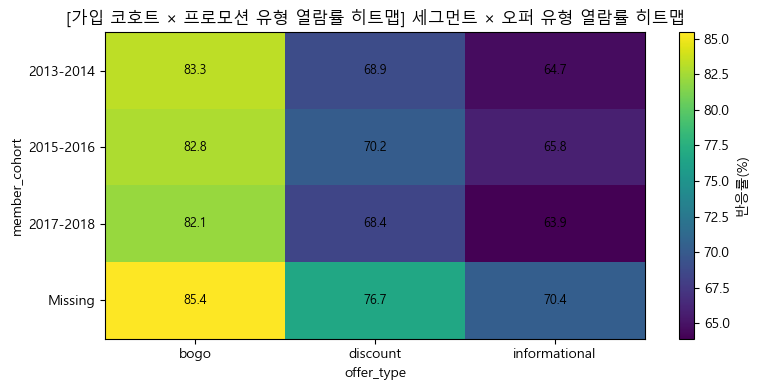

,member_cohort,offer_type,received_cnt,viewed_cnt,rv_rate
0,2013-2014,bogo,1667,1388,83.263347
1,2013-2014,discount,1686,1162,68.920522
2,2013-2014,informational,846,547,64.657210
3,2015-2016,bogo,8260,6837,82.772397
4,2015-2016,discount,8295,5822,70.186860
5,2015-2016,informational,4115,2707,65.783718
6,2017-2018,bogo,16610,13640,82.119205
7,2017-2018,discount,16683,11409,68.386981
8,2017-2018,informational,8339,5331,63.928529
9,Missing,bogo,3962,3385,85.436648


In [31]:
# ============================================================
# 세그먼트 × offer_type 열람률 히트맵
# ============================================================
plot_segment_offer_heatmap(
    gender_offer_rv_summary,
    'gender_group',
    'rv_rate',
    '성별 × 프로모션 유형 열람률 히트맵'
)

plot_segment_offer_heatmap(
    age_offer_rv_summary,
    'age_group',
    'rv_rate',
    '연령대 × 프로모션 유형 열람률 히트맵'
)

plot_segment_offer_heatmap(
    income_offer_rv_summary,
    'income_group',
    'rv_rate',
    '소득대 × 프로모션 유형 열람률 히트맵'
)

plot_segment_offer_heatmap(
    cohort_offer_rv_summary,
    'member_cohort',
    'rv_rate',
    '가입 코호트 × 프로모션 유형 열람률 히트맵'
)

# 1. 어떤 고객 세그먼트가 어떤 프로모션에 더 잘 반응하는가(열람)?
종합 보고서

- received → viewed : 열람률
    - 오퍼가 실제로 고객에게 읽혔는가

- received → completed : 전체 완료율
    - 오퍼를 받은 사람 중 최종적으로 조건 충족까지 간 비율
    
- received → viewed → completed : 정상 퍼널 완료율
    - received 이후 viewed를 거치고, 그 다음 completed까지 순서대로 간 비율

## 1. 성별 세그먼트 해석

성별 전체 열람률을 보면\
여성(F)은 73.9%, 남성(M)은 72.9%로 나타나\
주요 성별 집단 간 차이는 크지 않았다.

즉, 성별은 오퍼를 '보는 단계'에서는 큰 차이를 만들지 않는 변수로 해석할 수 있다.\
다만 기타(O)와 Missing 집단은 열람률이 상대적으로 높게 나타났지만,\
해당 집단은 규모와 데이터 해석 측면에서 주의가 필요하므로 보조적으로만 참고하는 것이 적절하다.

오퍼 유형별로 보면\
bogo는 여성 82.6%, 남성 82.1%로 거의 동일하게 가장 높은 열람률을 보였다.\
discount는 여성 70.4%, 남성 67.7%로 여성이 소폭 높았고,\
informational은 여성 63.7%, 남성 64.7%로 큰 차이 없이 비슷한 수준이었다.

결과적으로 성별 기준에서는\
특정 성별이 압도적으로 더 반응한다기보다,\
남녀 모두 bogo 유형에 가장 잘 반응하고\
discount와 informational은 그보다 낮은 열람률을 보이는 공통 패턴이 확인된다.

## 2. 연령대 세그먼트 해석

연령대 전체 열람률을 보면\
40–49세가 77.7%로 가장 높았고,\
50–59세 73.9%, 60–69세 74.0%, 70세 이상 73.2%로 뒤를 이었다.\
반면 18–29세는 68.1%로 가장 낮아\
젊은 층일수록 오퍼를 실제로 확인하는 비율이 낮은 편으로 나타났다.

오퍼 유형별로 보면\
bogo는 거의 모든 연령대에서 81~85% 수준으로 가장 높은 열람률을 보였다.\
특히 40–49세는 bogo 열람률이 85.5%로 가장 높았다

discount는 연령대별 차이가 더 뚜렷했다.\
18–29세는 59.1%로 가장 낮았고,\
40–49세는 72.9%, 60–69세는 71.8%로 상대적으로 높게 나타났다.

informational 역시\
18–29세 59.8%, 30–39세 63.5%, 40–49세 71.1%로\
연령대에 따라 열람률 차이가 존재했다.

결과적으로 연령대 기준에서는\
20대의 열람 반응이 가장 약하고,\
40대 이상에서 오퍼 확인 비율이 더 높게 나타났다.\
특히 bogo는 전 연령대에서 강한 열람 반응을 보이며,\
discount와 informational은 연령대에 따라 차이가 더 크게 나타난다.

## 3. 소득대 세그먼트 해석

소득대 전체 열람률을 보면\
50k–69k가 77.2%로 가장 높았고,\
70k–89k는 76.0%, 90k+는 71.8%,\
30k–49k는 67.0%로 가장 낮게 나타났다.

즉, 소득이 아주 높을수록 무조건 열람률이 높아진다기보다는\
중상위 소득 구간에서 오퍼 열람 반응이 가장 강하게 나타나는 구조로 볼 수 있다.

오퍼 유형별로 보면\
bogo는 50k–69k에서 85.3%, 70k–89k에서 83.4%로 높게 나타났고,\
30k–49k와 90k+는 각각 79.3%, 79.6% 수준이었다.

discount는\
30k–49k가 58.7%로 가장 낮았고,\
50k–69k는 72.6%, 70k–89k는 73.6%로 높게 나타났다.\
90k+도 70.5%로 낮지 않은 수준이지만,\
중간 소득대보다 아주 높지는 않았다

informational은 전체적으로 열람률이 더 낮았고,\
50k–69k에서 70.5%로 가장 높았으며\
90k+에서는 58.6%로 상대적으로 낮았다.

결과적으로 소득대 기준에서는\
저소득 구간의 열람 반응이 가장 약하고,\
50k–89k 구간에서 전반적으로 가장 안정적인 열람 반응이 나타났다.\
따라서 열람 단계 기준 타깃 반응층은\
중간~중상위 소득대라고 해석할 수 있다.

## 4. 가입 코호트 세그먼트 해석

가입 코호트 전체 열람률을 보면\
2015–2016 가입 고객이 74.3%로 가장 높았고,\
2013–2014는 73.8%, 2017–2018은 73.0%로 나타났다.

즉, 가입 시점에 따른 차이는 존재하지만\
성별이나 연령대에 비해 그 격차는 크지 않은 편이다.

오퍼 유형별로 보면\
bogo는 2013–2014 83.3%, 2015–2016 82.8%, 2017–2018 82.1%로\
모든 코호트에서 매우 비슷하게 높게 나타났다.

discount는\
2015–2016이 70.2%로 가장 높았고,\
2013–2014는 68.9%, 2017–2018은 68.4%였다.

informational 역시\
2015–2016이 65.8%로 가장 높았고,\
2013–2014는 64.7%, 2017–2018은 63.9%로 큰 차이는 아니지만\
기존 가입층이 조금 더 잘 확인하는 경향이 보였다.

결과적으로 가입 코호트 기준에서는\
2015–2016 가입 고객의 열람 반응이 가장 높지만,\
전체적으로는 코호트 차이보다\
오퍼 유형 자체의 차이가 더 크게 작용한다고 볼 수 있다.

## 종합 해석
전체적으로 고객 세그먼트별 열람률을 비교한 결과,\
오퍼를 '보는 단계'에서는 성별 차이는 크지 않았고,\
연령대와 소득대에서 상대적으로 더 뚜렷한 차이가 나타났다.\

연령대 기준으로는 18–29세의 열람률이 가장 낮았고,\
40대 이상에서 더 높은 열람 반응이 확인되었다.\
소득대 기준으로는 30k–49k가 가장 낮았으며,\
50k–89k 구간에서 전반적으로 높은 열람률이 나타났다.

프로모션 유형별로는 거의 모든 세그먼트에서\
bogo의 열람률이 가장 높았고,\
discount가 그 다음, informational이 가장 낮은 패턴이 반복되었다.

1번 분석은\
'누가 실제로 오퍼를 열어보는가'를 보여주는 단계이며,\
열람 단계에서는 특히 연령대와 소득대 차이가 의미 있게 나타났다고 해석할 수 있다.\
반면 실제 완료까지 이어지는 차이는 다음 3번 분석에서 따로 확인하는 것이 적절하다.

# 2. 어떤 채널 조합에서 오퍼 반응률이 더 높은가?
오퍼의 채널 조합에 따라 반응률 차이가 있는가?

- 채널 종류
    - web
    - email
    - mobile
    - social


- 사용 지표
    - `converted_rv` : 오퍼를 받은 뒤 실제로 열람했는가
    - `converted_rc` : 오퍼를 받은 뒤 완료했는가
    - `converted_rvc` : 오퍼를 받고, 열람 후, 완료까지 이어졌는가

## 1. 채널 조합 컬럼 생성

In [32]:
# ============================================================
# 1. 채널 조합 컬럼 생성
# ============================================================

channel_cols = ['web', 'email', 'mobile', 'social']

# 안전하게 복사
funnel_channel = funnel_seg.copy()

# 혹시 결측이 있으면 0으로 처리
for col in channel_cols:
    funnel_channel[col] = funnel_channel[col].fillna(0).astype(int)

# channel_combo 생성
def make_channel_combo(row):
    channels = []
    
    if row['web'] == 1:
        channels.append('web')
    if row['email'] == 1:
        channels.append('email')
    if row['mobile'] == 1:
        channels.append('mobile')
    if row['social'] == 1:
        channels.append('social')
    
    if len(channels) == 0:
        return 'none'
    else:
        return ' + '.join(channels)

funnel_channel['channel_combo'] = funnel_channel.apply(make_channel_combo, axis=1)

print("채널 조합 종류 수:", funnel_channel['channel_combo'].nunique())
display(
    funnel_channel[
        ['offer_id', 'offer_type', 'web', 'email', 'mobile', 'social', 'channel_combo']
    ].drop_duplicates().sort_values(['offer_type', 'channel_combo'])
)

채널 조합 종류 수: 4


,offer_id,offer_type,web,email,mobile,social,channel_combo
14,ae264e3637204a6fb9bb56bc8210ddfd,bogo,0,1,1,1,email + mobile + social
11,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,1,1,1,0,web + email + mobile
3,f19421c1d4aa40978ebb69ca19b0e20d,bogo,1,1,1,1,web + email + mobile + social
12,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,1,1,1,1,web + email + mobile + social
7,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,1,1,0,0,web + email
0,2906b810c7d4411798c6938adc9daaa5,discount,1,1,1,0,web + email + mobile
4,fafdcd668e3743c1bb461111dcafc2a4,discount,1,1,1,1,web + email + mobile + social
8,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,1,1,1,1,web + email + mobile + social
2,5a8bc65990b245e5a138643cd4eb9837,informational,0,1,1,1,email + mobile + social
1,3f207df678b143eea3cee63160fa8bed,informational,1,1,1,0,web + email + mobile


## 2. 채널 조합별 기본 분포 확인

In [33]:
# ============================================================
# 2. 채널 조합별 기본 분포 확인
# ============================================================

channel_dist = (
    funnel_channel['channel_combo']
    .value_counts(dropna=False)
    .rename_axis('channel_combo')
    .reset_index(name='received_cnt')
)

print("=" * 70)
print("채널 조합별 received 건수")
print("=" * 70)
display(channel_dist)

채널 조합별 received 건수


,channel_combo,received_cnt
0,web + email + mobile + social,30407
1,web + email + mobile,22926
2,email + mobile + social,15276
3,web + email,7668


## 3. 채널 조합별 전체 반응률 요약표

In [34]:
# ============================================================
# 3. 채널 조합별 전체 반응률 요약표
# ============================================================

channel_summary = (
    funnel_channel
    .groupby('channel_combo', dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),
        viewed_cnt=('converted_rv', 'sum'),
        completed_cnt=('converted_rc', 'sum'),
        strict_completed_cnt=('converted_rvc', 'sum')
    )
    .reset_index()
)

channel_summary['rv_rate'] = channel_summary['viewed_cnt'] / channel_summary['received_cnt'] * 100
channel_summary['rc_rate'] = channel_summary['completed_cnt'] / channel_summary['received_cnt'] * 100
channel_summary['rvc_rate'] = channel_summary['strict_completed_cnt'] / channel_summary['received_cnt'] * 100

channel_summary = channel_summary.sort_values('received_cnt', ascending=False).reset_index(drop=True)

print("=" * 70)
print("채널 조합별 전체 반응률 요약표")
print("=" * 70)
display(channel_summary)

채널 조합별 전체 반응률 요약표


,channel_combo,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,web + email + mobile + social,30407,29100,17922,15299,95.701648,58.940376,50.314072
1,web + email + mobile,22926,11987,8261,4252,52.285615,36.033325,18.546628
2,email + mobile + social,15276,12828,3635,2613,83.974863,23.795496,17.105263
3,web + email,7668,2652,3334,1332,34.585290,43.479395,17.370892


## 4. 채널 조합 × offer_type 요약표

In [35]:
# ============================================================
# 4. 채널 조합 × offer_type 반응률 요약표
# ============================================================

channel_offer_summary = (
    funnel_channel
    .groupby(['channel_combo', 'offer_type'], dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),
        viewed_cnt=('converted_rv', 'sum'),
        completed_cnt=('converted_rc', 'sum'),
        strict_completed_cnt=('converted_rvc', 'sum')
    )
    .reset_index()
)

channel_offer_summary['rv_rate'] = channel_offer_summary['viewed_cnt'] / channel_offer_summary['received_cnt'] * 100
channel_offer_summary['rc_rate'] = channel_offer_summary['completed_cnt'] / channel_offer_summary['received_cnt'] * 100
channel_offer_summary['rvc_rate'] = channel_offer_summary['strict_completed_cnt'] / channel_offer_summary['received_cnt'] * 100

channel_offer_summary = channel_offer_summary.sort_values(
    ['channel_combo', 'offer_type']
).reset_index(drop=True)

print("=" * 70)
print("채널 조합 × offer_type 반응률 요약표")
print("=" * 70)
display(channel_offer_summary)

채널 조합 × offer_type 반응률 요약표


,channel_combo,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,email + mobile + social,bogo,7658,6679,3635,2613,87.215983,47.466701,34.121180
1,email + mobile + social,informational,7618,6149,0,0,80.716724,0.000000,0.000000
2,web + email,discount,7668,2652,3334,1332,34.585290,43.479395,17.370892
3,web + email + mobile,bogo,7677,4128,4303,2124,53.771004,56.050541,27.667057
4,web + email + mobile,discount,7632,4061,3958,2128,53.210168,51.860587,27.882600
5,web + email + mobile,informational,7617,3798,0,0,49.862150,0.000000,0.000000
6,web + email + mobile + social,bogo,15164,14443,7563,6287,95.245318,49.874703,41.460037
7,web + email + mobile + social,discount,15243,14657,10359,9012,96.155612,67.959063,59.122220


## 5. 시각화

### 그래프 함수

In [36]:
# ============================================================
# 6. 채널 조합 × offer_type 반응률 그래프 함수
# ============================================================

def plot_channel_offer(summary_df, rate_col, group_title='채널 조합'):
    
    df_a = summary_df.copy()
    
    offer_order = ['bogo', 'discount', 'informational']
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )
    
    channel_order = (
        df_a.groupby('channel_combo')['received_cnt']
        .sum()
        .sort_values(ascending=False)
        .index
        .tolist()
    )
    
    df_a['channel_combo'] = pd.Categorical(
        df_a['channel_combo'],
        categories=channel_order,
        ordered=True
    )
    
    df_a = df_a.sort_values(['offer_type', 'channel_combo'])
    
    rate_name_map = {
        'rv_rate': '열람률',
        'rc_rate': '완료율',
        'rvc_rate': '엄격 완료율'
    }
    rate_name = rate_name_map.get(rate_col, rate_col)
    
    offer_types = [x for x in offer_order if x in df_a['offer_type'].dropna().unique()]
    n_rows = len(offer_types)
    
    fig, axes = plt.subplots(n_rows, 1, figsize=(12, n_rows * 4))
    
    if n_rows == 1:
        axes = [axes]
    
    for i, offer in enumerate(offer_types):
        temp_df = df_a[df_a['offer_type'] == offer].copy()
        
        sns.barplot(
            data=temp_df,
            x='channel_combo',
            y=rate_col,
            ax=axes[i]
        )
        
        axes[i].set_title(f"{offer} - {rate_name}", fontsize=12, fontweight='bold')
        axes[i].set_xlabel("")
        axes[i].set_ylabel("반응률(%)")
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].grid(axis='y', linestyle='--', alpha=0.3)
        
        for p in axes[i].patches:
            height = p.get_height()
            if pd.notna(height):
                axes[i].annotate(
                    f"{height:.1f}",
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    xytext=(0, 3),
                    textcoords='offset points'
                )
    
    fig.suptitle(f"[{group_title}] 채널 조합 × 프로모션 유형 {rate_name} 비교", fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    
    return df_a

In [37]:
# ============================================================
# 5. 채널 조합별 전체 반응률 그래프 함수
# ============================================================

def plot_channel_summary(summary_df, group_title='채널 조합'):
    
    df_a = summary_df.copy()
    df_a = df_a.sort_values('received_cnt', ascending=False)
    
    metric_cols = ['rv_rate', 'rc_rate', 'rvc_rate']
    metric_names = ['열람률', '완료율', '엄격 완료율']
    
    n_rows = len(metric_cols)
    fig, axes = plt.subplots(n_rows, 1, figsize=(12, n_rows * 4))
    
    if n_rows == 1:
        axes = [axes]
    
    for i, (metric_col, metric_name) in enumerate(zip(metric_cols, metric_names)):
        sns.barplot(
            data=df_a,
            x='channel_combo',
            y=metric_col,
            ax=axes[i]
        )
        
        axes[i].set_title(f"{metric_name} 비교", fontsize=12, fontweight='bold')
        axes[i].set_xlabel("")
        axes[i].set_ylabel("반응률(%)")
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].grid(axis='y', linestyle='--', alpha=0.3)
        
        for p in axes[i].patches:
            height = p.get_height()
            if pd.notna(height):
                axes[i].annotate(
                    f"{height:.1f}",
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    xytext=(0, 3),
                    textcoords='offset points'
                )
    
    fig.suptitle(f"[{group_title}] 전체 반응률 비교", fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    
    return df_a

In [38]:
# ============================================================
# 채널 조합 × offer_type 히트맵 함수
# ============================================================

def plot_channel_offer_heatmap(summary_df, rate_col, group_title='채널 조합'):
    
    df_a = summary_df.copy()
    
    offer_order = ['bogo', 'discount', 'informational']
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )
    
    channel_order = (
        df_a.groupby('channel_combo')['received_cnt']
        .sum()
        .sort_values(ascending=False)
        .index
        .tolist()
    )
    
    df_a['channel_combo'] = pd.Categorical(
        df_a['channel_combo'],
        categories=channel_order,
        ordered=True
    )
    
    df_a = df_a.sort_values(['channel_combo', 'offer_type'])
    
    rate_name_map = {
        'rv_rate': '열람률',
        'rc_rate': '완료율',
        'rvc_rate': '엄격 완료율'
    }
    rate_name = rate_name_map.get(rate_col, rate_col)
    
    pivot_df = df_a.pivot(
        index='channel_combo',
        columns='offer_type',
        values=rate_col
    )
    
    fig, ax = plt.subplots(figsize=(8, max(4, len(pivot_df) * 0.8)))
    im = ax.imshow(pivot_df, aspect='auto')
    
    ax.set_xticks(range(len(pivot_df.columns)))
    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticks(range(len(pivot_df.index)))
    ax.set_yticklabels(pivot_df.index)
    
    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            value = pivot_df.iloc[i, j]
            if pd.notna(value):
                ax.text(
                    j, i,
                    f"{value:.1f}",
                    ha='center',
                    va='center',
                    fontsize=9
                )
    
    plt.title(f"[{group_title}] 채널 조합 × 프로모션 유형 {rate_name} 히트맵")
    plt.xlabel("offer_type")
    plt.ylabel("channel_combo")
    plt.colorbar(im, ax=ax, label='반응률(%)')
    plt.tight_layout()
    plt.show()
    
    return df_a

### 그래프 출력

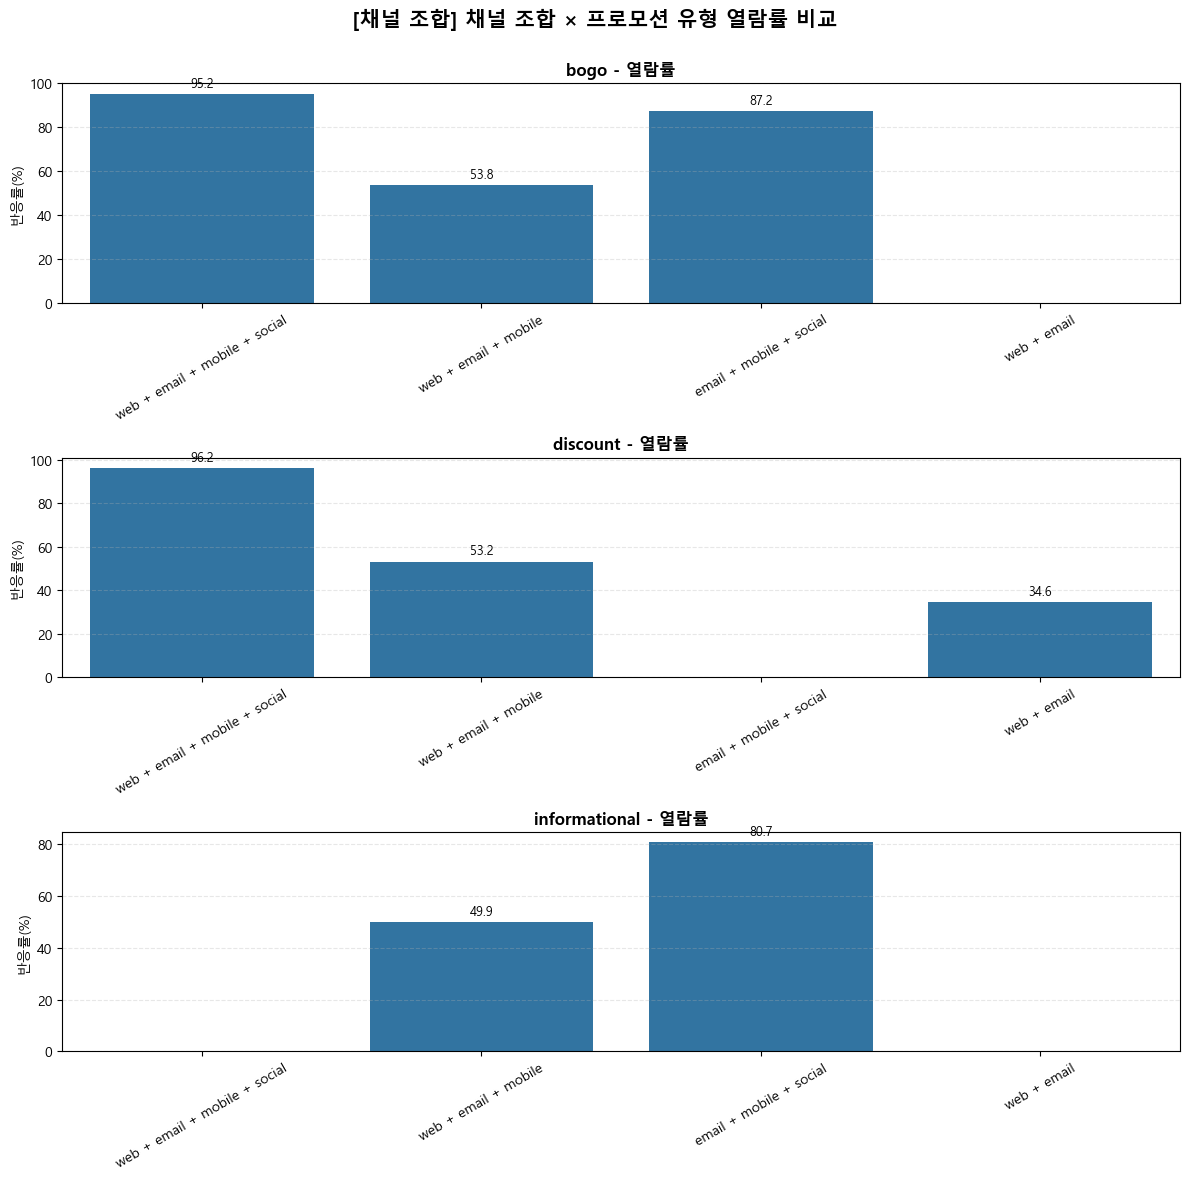

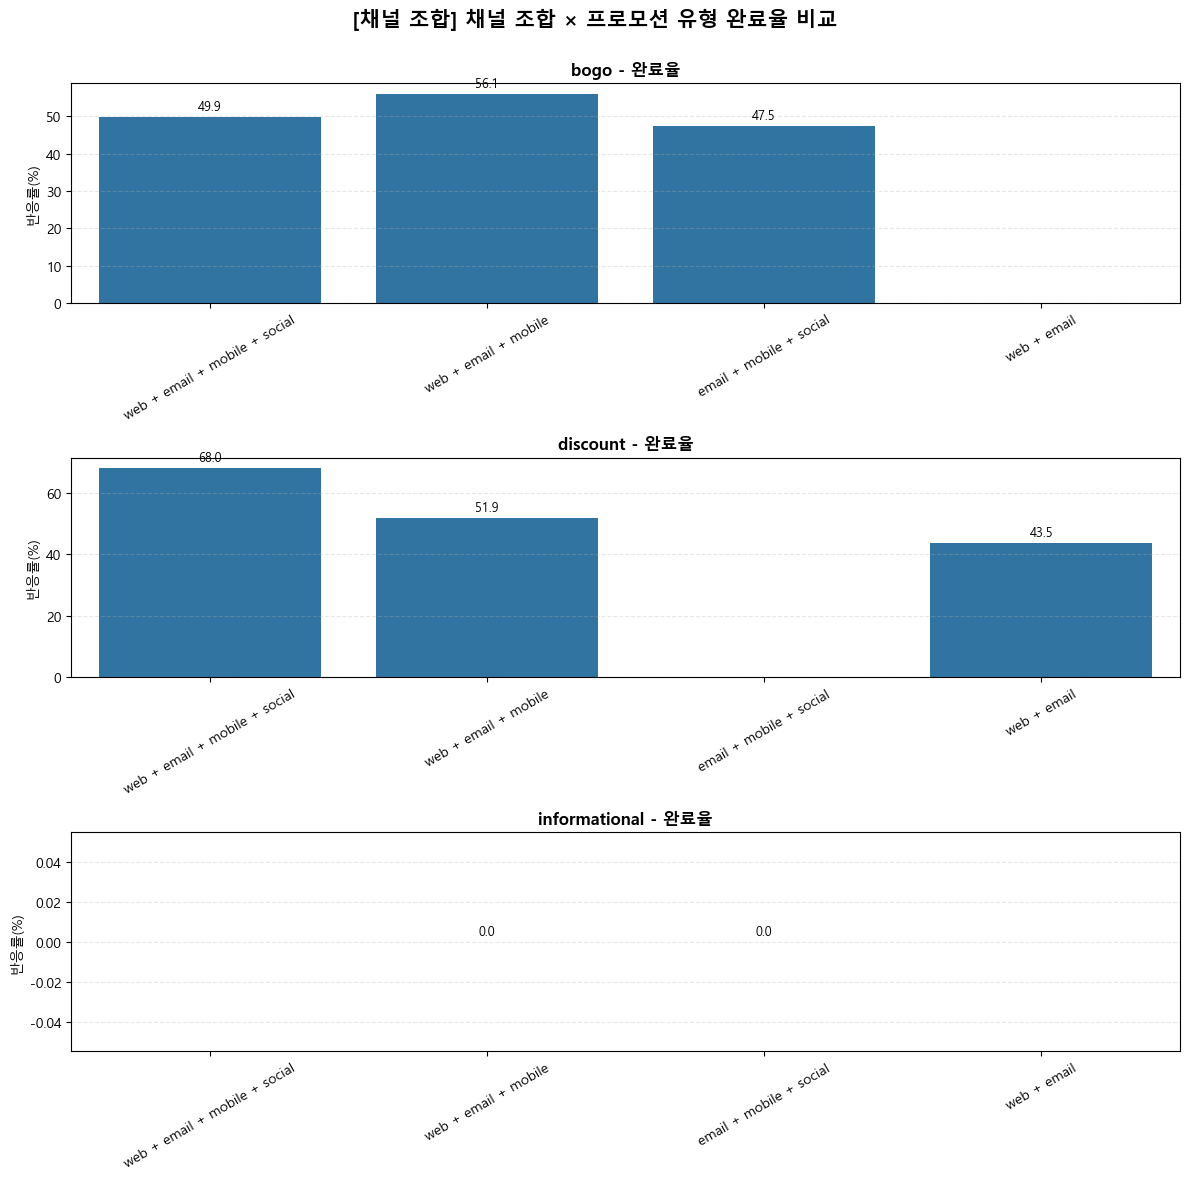

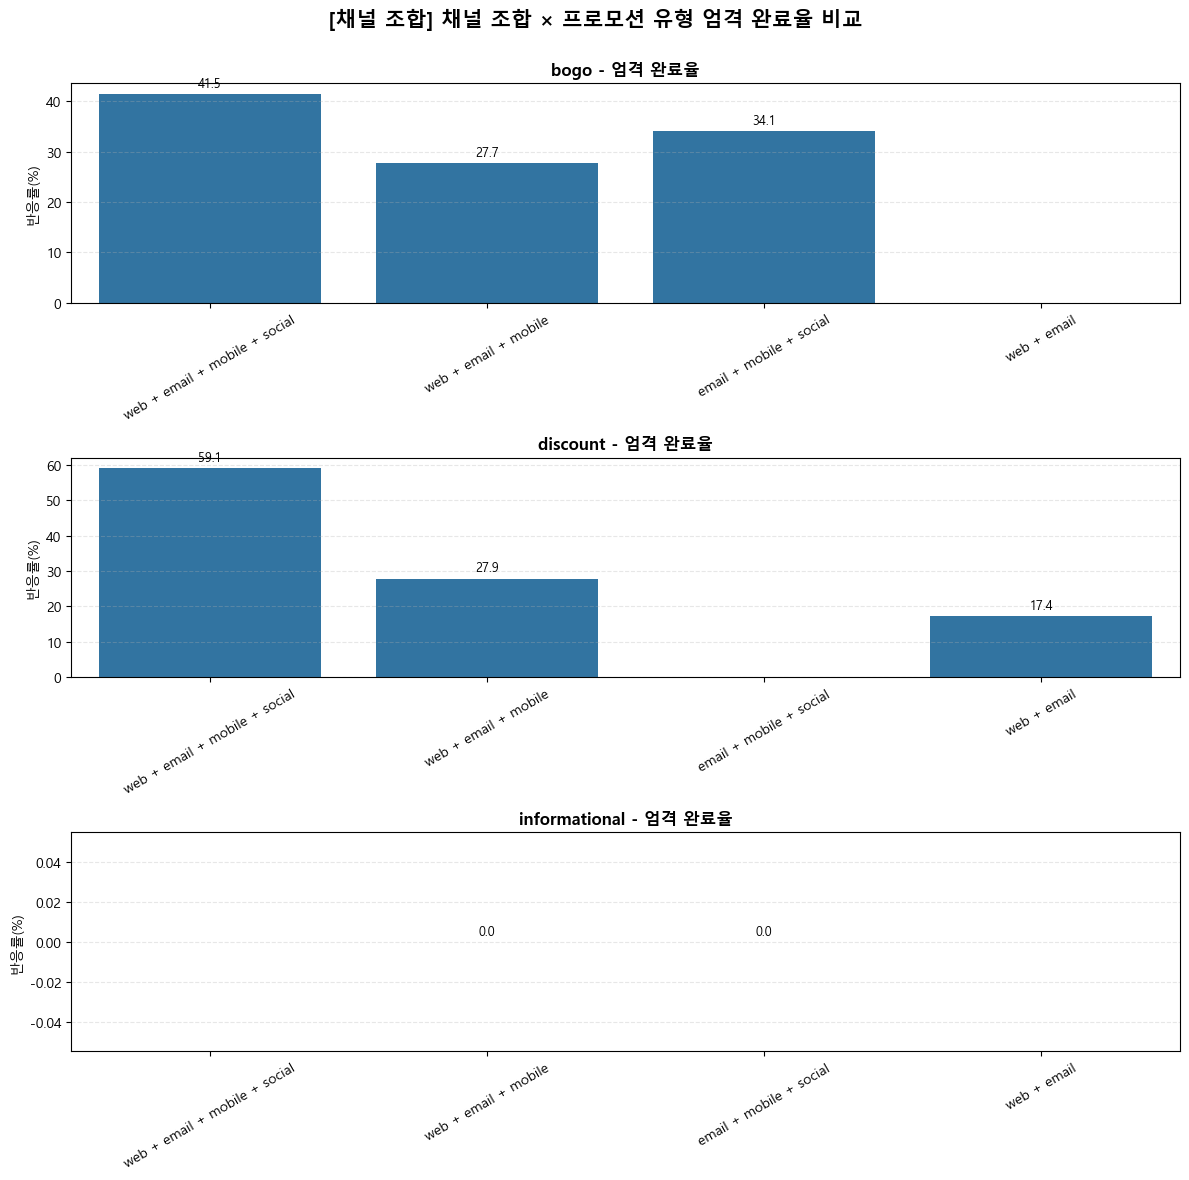

,channel_combo,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
6,web + email + mobile + social,bogo,15164,14443,7563,6287,95.245318,49.874703,41.460037
3,web + email + mobile,bogo,7677,4128,4303,2124,53.771004,56.050541,27.667057
0,email + mobile + social,bogo,7658,6679,3635,2613,87.215983,47.466701,34.121180
7,web + email + mobile + social,discount,15243,14657,10359,9012,96.155612,67.959063,59.122220
4,web + email + mobile,discount,7632,4061,3958,2128,53.210168,51.860587,27.882600
2,web + email,discount,7668,2652,3334,1332,34.585290,43.479395,17.370892
5,web + email + mobile,informational,7617,3798,0,0,49.862150,0.000000,0.000000
1,email + mobile + social,informational,7618,6149,0,0,80.716724,0.000000,0.000000


In [39]:
plot_channel_offer(channel_offer_summary, 'rv_rate', '채널 조합')
plot_channel_offer(channel_offer_summary, 'rc_rate', '채널 조합')
plot_channel_offer(channel_offer_summary, 'rvc_rate', '채널 조합')

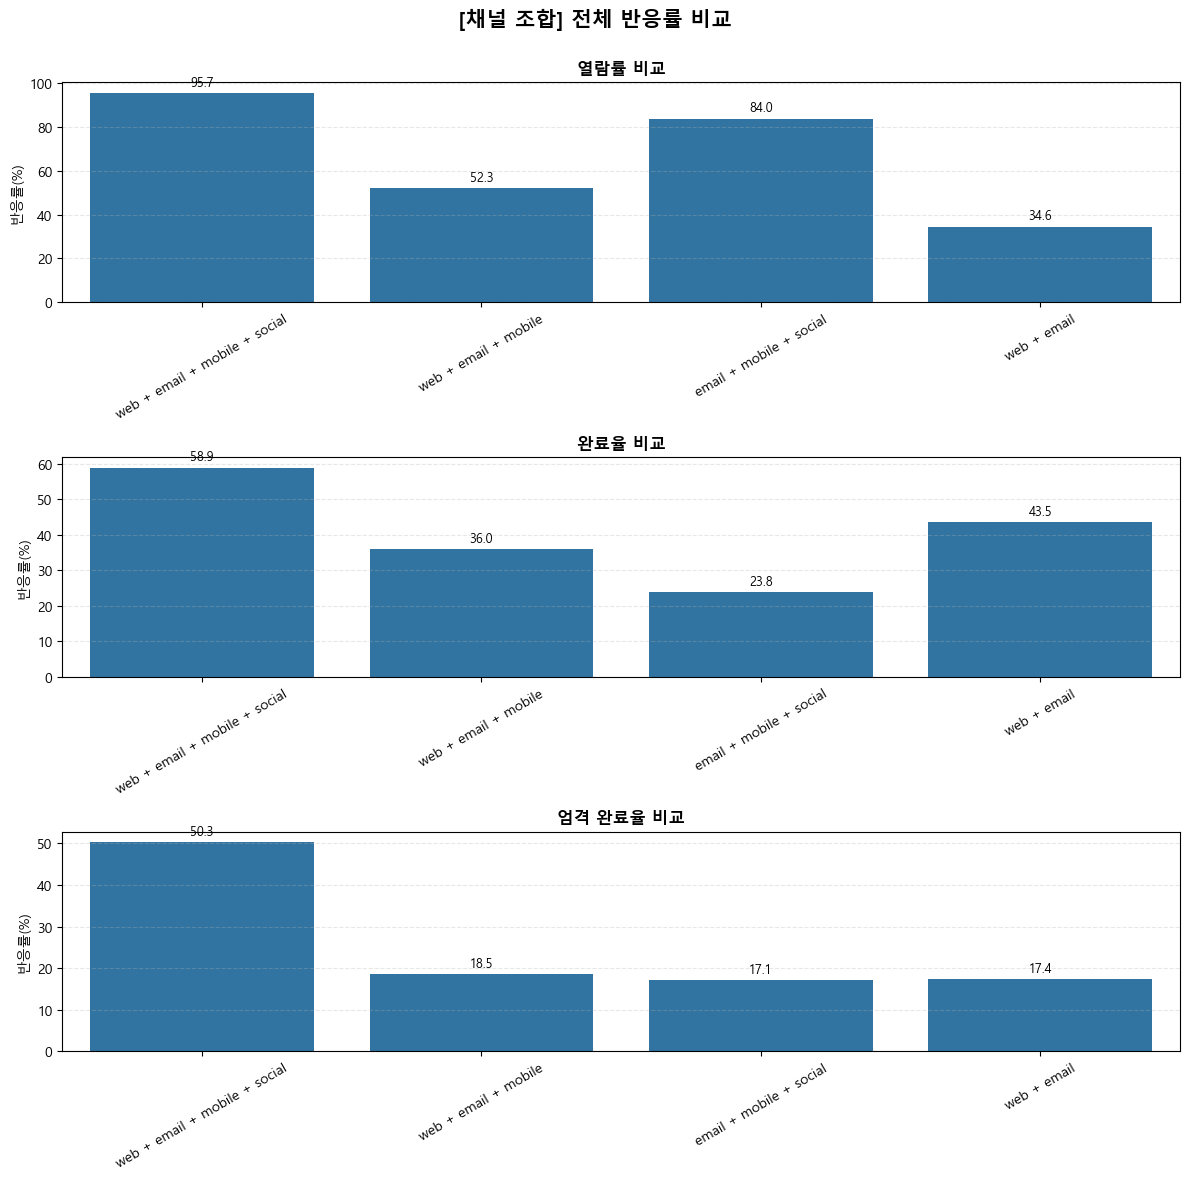

,channel_combo,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,web + email + mobile + social,30407,29100,17922,15299,95.701648,58.940376,50.314072
1,web + email + mobile,22926,11987,8261,4252,52.285615,36.033325,18.546628
2,email + mobile + social,15276,12828,3635,2613,83.974863,23.795496,17.105263
3,web + email,7668,2652,3334,1332,34.585290,43.479395,17.370892


In [40]:
plot_channel_summary(channel_summary, '채널 조합')

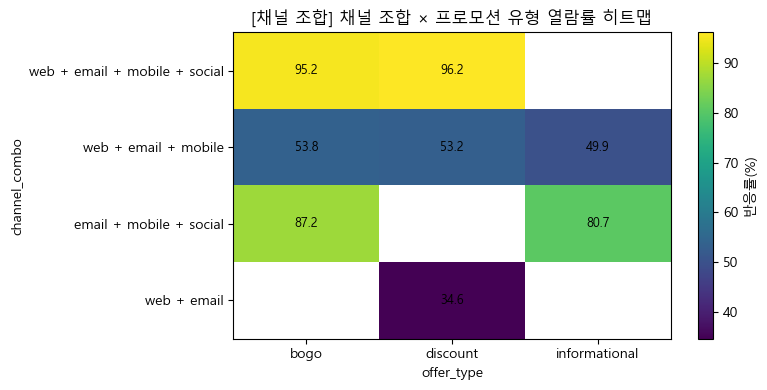

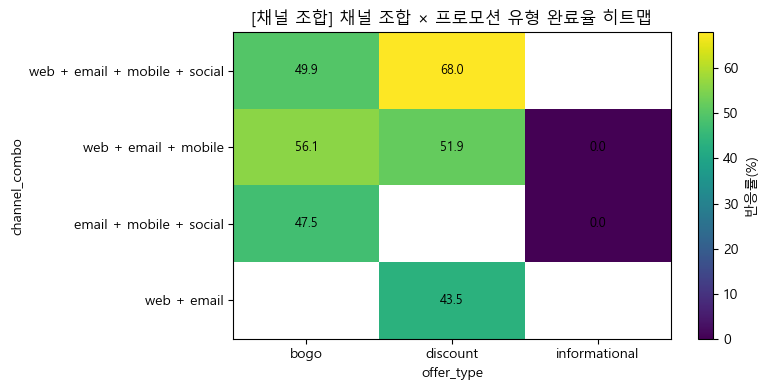

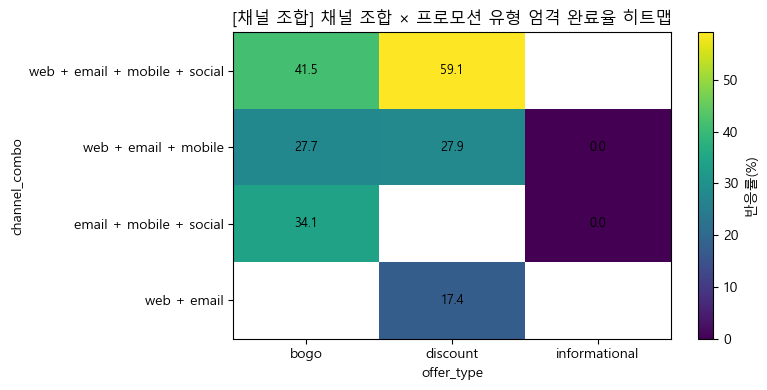

,channel_combo,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
6,web + email + mobile + social,bogo,15164,14443,7563,6287,95.245318,49.874703,41.460037
7,web + email + mobile + social,discount,15243,14657,10359,9012,96.155612,67.959063,59.122220
3,web + email + mobile,bogo,7677,4128,4303,2124,53.771004,56.050541,27.667057
4,web + email + mobile,discount,7632,4061,3958,2128,53.210168,51.860587,27.882600
5,web + email + mobile,informational,7617,3798,0,0,49.862150,0.000000,0.000000
0,email + mobile + social,bogo,7658,6679,3635,2613,87.215983,47.466701,34.121180
1,email + mobile + social,informational,7618,6149,0,0,80.716724,0.000000,0.000000
2,web + email,discount,7668,2652,3334,1332,34.585290,43.479395,17.370892


In [41]:
plot_channel_offer_heatmap(channel_offer_summary, 'rv_rate', '채널 조합')
plot_channel_offer_heatmap(channel_offer_summary, 'rc_rate', '채널 조합')
plot_channel_offer_heatmap(channel_offer_summary, 'rvc_rate', '채널 조합')

# 2. 어떤 채널 조합에서 오퍼 반응률이 더 높은가?
종합 보고서

## 1. 채널 조합별 해석
전체 채널 조합 중 가장 높은 반응을 보인 것은 web + email + mobile + social 조합이었다.\
이 조합은 열람률이 95.7%, 완료율이 58.9%, 정상 퍼널 완료율이 50.3%로 가장 높게 나타났다.
즉, 오퍼를 받은 대부분의 고객이 실제로 오퍼를 확인했고, 그중 상당수가 열람 이후 완료까지 이어졌다는 뜻이다.

반면 email + mobile + social 조합은 열람률이 84.0%로 높은 편이었지만, 완료율은 23.8%, 정상 퍼널 완료율은 17.1%로 낮게 나타났다.\
즉, 오퍼 자체는 비교적 잘 확인되었지만, 그 이후 실제 완료 행동으로는 잘 이어지지 못했다는 뜻이다.

web + email + mobile 조합은 열람률 52.3%, 완료율 36.0%, 정상 퍼널 완료율 18.5%로 중간 수준의 반응을 보였다.

web + email 조합은 열람률이 34.6%로 가장 낮았는데, 완료율은 43.5%로 열람률보다 높게 나타났다.

- 주의 포인트
    - web + email 조합은 discount 오퍼만 포함한다.
    - web + email + mobile + social 조합은 bogo와 discount 중심이다.
    - email + mobile + social 조합은 bogo와 informational이 섞여 있다.


## 2. 종합해석
전체적으로 보면 web + email + mobile + social 조합이 가장 우수한 반응을 보였고,\
열람률, 완료율, 정상 퍼널 완료율 모두에서 가장 좋은 성과를 기록했다.
따라서 현재 데이터 기준에서는 이 조합이 가장 강한 반응을 이끈 채널 구성이라고 볼 수 있다.

email + mobile + social은 열람은 잘 되었지만 완료까지는 잘 이어지지 않았고,\
web + email, web + email + mobile은 퍼널 흐름이 다소 약하게 나타났다.

결론적으로,\
채널 조합에 따라 보게 만드는 것과, 완료하게 만드는 것이 다르게 나타나는 점이다.\
다만, 이 효과는 오퍼 유형과 함께 해석해야 하므로,\
다음 단계에서 고객군과 프로모션 유형을 함께 보며 더 구체적으로 해석하는 것이 필요하다.

# 3. 어떤 고객군이 오퍼를 본 뒤 완료까지 더 잘 이어지는가?
오퍼를 실제로 열람한 고객들 중, 어떤 고객군이 completed까지 더 잘 이어지는가?

received 기준 반응 분석과 다르게, `viewed`를 기준으로 completed 전환을 본다.

- 사용 지표
    - `converted_vc` : viewed → completed 전환 여부
    - `vc_rate` : viewed 대비 completed 비율
    - `vc_time_diff` : viewed 후 completed까지 걸린 시간

## 1. viewed 기준 분석용 데이터 준비

In [42]:
# ============================================================
# 1. viewed 기준 분석용 데이터 준비
# ============================================================

funnel_vc = funnel_seg.copy()

# viewed된 건만 남김
funnel_vc = funnel_vc[funnel_vc['converted_rv'] == 1].copy()

# completed 해석이 가능한 유형만 남김
funnel_vc_main = funnel_vc[funnel_vc['offer_type'].isin(['bogo', 'discount'])].copy()

print("viewed 기준 전체 행 수:", len(funnel_vc))
print("viewed 기준 고객 수:", funnel_vc['customer_id'].nunique())
print()

print("bogo / discount 기준 viewed 행 수:", len(funnel_vc_main))
print("bogo / discount 기준 viewed 고객 수:", funnel_vc_main['customer_id'].nunique())
display(funnel_vc_main.head())

viewed 기준 전체 행 수: 56567
viewed 기준 고객 수: 16793

bogo / discount 기준 viewed 행 수: 46620
bogo / discount 기준 viewed 고객 수: 16489


,customer_id,offer_id,offer_type,offer_reward,difficulty,duration,web,email,mobile,social,time_received,offer_end_time,rv_time_diff,rc_time_diff,vc_time_diff,converted_rv,converted_rc,converted_vc,converted_rvc,gender,age,income,became_member_on,gender_group,age_clean,age_group,income_group,member_year,member_cohort
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,408,528.0,48.0,6.0,NaN,1,1,0,0,M,33.0,72000.0,2017-04-21,M,33.0,30-39,70k-89k,2017,2017-2018
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount,2.0,10.0,10.0,1.0,1.0,1.0,1.0,504,744.0,36.0,24.0,NaN,1,1,0,0,M,33.0,72000.0,2017-04-21,M,33.0,30-39,70k-89k,2017,2017-2018
5,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,168,288.0,48.0,NaN,NaN,1,0,0,0,NaN,NaN,NaN,<NA>,Missing,NaN,Missing,Missing,<NA>,Missing
6,00116118485d4dfda04fdbaba9a87b5c,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5.0,5.0,5.0,1.0,1.0,1.0,1.0,576,696.0,54.0,NaN,NaN,1,0,0,0,NaN,NaN,NaN,<NA>,Missing,NaN,Missing,Missing,<NA>,Missing
7,0011e0d4e6b944f998e987f904e8c1e5,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,5.0,20.0,10.0,1.0,1.0,0.0,0.0,408,648.0,24.0,168.0,144.0,1,1,1,1,O,40.0,57000.0,2018-01-09,O,40.0,40-49,50k-69k,2018,2017-2018


## 2. viewed 기준 offer_type 분포

In [43]:
# ============================================================
# 2. viewed 기준 offer_type 분포
# ============================================================
view_offer_dist = (
    funnel_vc_main['offer_type']
    .value_counts(dropna=False)
    .rename_axis('offer_type')
    .reset_index(name='viewed_cnt')
)

print("=" * 70)
print("viewed 기준 offer_type 분포")
print("=" * 70)
display(view_offer_dist)

viewed 기준 offer_type 분포


,offer_type,viewed_cnt
0,bogo,25250
1,discount,21370


## 3. 고객군별 VC 요약 함수

In [44]:
# ============================================================
# 3. 고객군별 viewed -> completed 요약 함수
# ============================================================
def make_segment_vc_summary(df, segment_col):
    summary = (
        df.groupby(segment_col, dropna=False)
        .agg(
            viewed_cnt=('customer_id', 'size'),
            completed_after_view_cnt=('converted_vc', 'sum'),
            avg_vc_time=('vc_time_diff', 'mean')
        )
        .reset_index()
    )
    
    summary['vc_rate'] = summary['completed_after_view_cnt'] / summary['viewed_cnt'] * 100
    summary = summary.sort_values('viewed_cnt', ascending=False).reset_index(drop=True)
    
    return summary

In [45]:
gender_vc_summary = make_segment_vc_summary(funnel_vc_main, 'gender_group')
age_vc_summary = make_segment_vc_summary(funnel_vc_main, 'age_group')
income_vc_summary = make_segment_vc_summary(funnel_vc_main, 'income_group')
cohort_vc_summary = make_segment_vc_summary(funnel_vc_main, 'member_cohort')

print("=" * 70)
print("gender_group 기준 viewed -> completed 요약")
print("=" * 70)
display(gender_vc_summary)

print("=" * 70)
print("age_group 기준 viewed -> completed 요약")
print("=" * 70)
display(age_vc_summary)

print("=" * 70)
print("income_group 기준 viewed -> completed 요약")
print("=" * 70)
display(income_vc_summary)

print("=" * 70)
print("member_cohort 기준 viewed -> completed 요약")
print("=" * 70)
display(cohort_vc_summary)

gender_group 기준 viewed -> completed 요약


,gender_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,M,22881,11655,47.171686,50.937459
1,F,16765,10507,40.514133,62.672234
2,Missing,6362,944,81.165254,14.838101
3,O,612,390,41.646154,63.725490


age_group 기준 viewed -> completed 요약


,age_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,50-59,9649,5682,42.248152,58.886931
1,60-69,8270,4761,44.514178,57.569528
2,70+,7772,4570,42.771991,58.800823
3,40-49,6537,3627,44.689826,55.484167
4,Missing,6373,952,80.722689,14.938020
5,30-39,4013,2119,45.227938,52.803389
6,18-29,4006,1785,48.235294,44.558163


income_group 기준 viewed -> completed 요약


,income_group,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,50k-69k,14087,7720,45.780311,54.802300
1,70k-89k,10593,6641,41.379310,62.692344
2,30k-49k,9391,4107,50.100804,43.733362
3,Missing,6362,944,81.165254,14.838101
4,90k+,6187,4084,38.619491,66.009374


member_cohort 기준 viewed -> completed 요약


,member_cohort,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,2017-2018,25049,11916,48.594159,47.570761
1,2015-2016,12659,9209,36.243675,72.746662
2,Missing,6362,944,81.165254,14.838101
3,2013-2014,2550,1427,55.286615,55.960784


## 4. 고객군 × offer_type VC 요약 함수

In [46]:
# ============================================================
# 4. 고객군 × offer_type viewed -> completed 요약 함수
# ============================================================
def make_segment_offer_vc_summary(df, segment_col):
    summary = (
        df.groupby([segment_col, 'offer_type'], dropna=False)
        .agg(
            viewed_cnt=('customer_id', 'size'),
            completed_after_view_cnt=('converted_vc', 'sum'),
            avg_vc_time=('vc_time_diff', 'mean')
        )
        .reset_index()
    )
    
    summary['vc_rate'] = summary['completed_after_view_cnt'] / summary['viewed_cnt'] * 100
    summary = summary.sort_values([segment_col, 'offer_type']).reset_index(drop=True)
    
    return summary

In [47]:
gender_offer_vc_summary = make_segment_offer_vc_summary(funnel_vc_main, 'gender_group')
age_offer_vc_summary = make_segment_offer_vc_summary(funnel_vc_main, 'age_group')
income_offer_vc_summary = make_segment_offer_vc_summary(funnel_vc_main, 'income_group')
cohort_offer_vc_summary = make_segment_offer_vc_summary(funnel_vc_main, 'member_cohort')

print("=" * 70)
print("gender_group × offer_type viewed -> completed 요약")
print("=" * 70)
display(gender_offer_vc_summary)

print("=" * 70)
print("age_group × offer_type viewed -> completed 요약")
print("=" * 70)
display(age_offer_vc_summary)

print("=" * 70)
print("income_group × offer_type viewed -> completed 요약")
print("=" * 70)
display(income_offer_vc_summary)

print("=" * 70)
print("member_cohort × offer_type viewed -> completed 요약")
print("=" * 70)
display(cohort_offer_vc_summary)

gender_group × offer_type viewed -> completed 요약


,gender_group,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,F,bogo,9065,5254,34.829463,57.959184
1,F,discount,7700,5253,46.199886,68.220779
2,M,bogo,12485,5281,36.985041,42.298759
3,M,discount,10396,6374,55.611547,61.312043
4,Missing,bogo,3385,297,49.979798,8.774003
5,Missing,discount,2977,647,95.480680,21.733289
6,O,bogo,315,192,36.843750,60.952381
7,O,discount,297,198,46.303030,66.666667


age_group × offer_type viewed -> completed 요약


,age_group,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,18-29,bogo,2298,790,33.660759,34.377720
1,18-29,discount,1708,995,59.807035,58.255269
2,30-39,bogo,2202,960,35.100000,43.596730
3,30-39,discount,1811,1159,53.616911,63.997791
4,40-49,bogo,3579,1738,36.514384,48.561051
5,40-49,discount,2958,1889,52.211752,63.860717
6,50-59,bogo,5183,2743,34.497266,52.923018
7,50-59,discount,4466,2939,49.482137,65.808330
8,60-69,bogo,4369,2237,37.654895,51.201648
9,60-69,discount,3901,2524,50.593502,64.701359


income_group × offer_type viewed -> completed 요약


,income_group,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,30k-49k,bogo,5379,1764,38.319728,32.794200
1,30k-49k,discount,4012,2343,58.970551,58.399801
2,50k-69k,bogo,7576,3610,36.034903,47.650475
3,50k-69k,discount,6511,4110,54.340146,63.123944
4,70k-89k,bogo,5598,3226,35.207688,57.627724
5,70k-89k,discount,4995,3415,47.209370,68.368368
6,90k+,bogo,3312,2127,34.849083,64.221014
7,90k+,discount,2875,1957,42.717425,68.069565
8,Missing,bogo,3385,297,49.979798,8.774003
9,Missing,discount,2977,647,95.480680,21.733289


member_cohort × offer_type viewed -> completed 요약


,member_cohort,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,2013-2014,bogo,1388,525,44.491429,37.824207
1,2013-2014,discount,1162,902,61.569845,77.624785
2,2015-2016,bogo,6837,4489,30.824683,65.657452
3,2015-2016,discount,5822,4720,41.397458,81.071797
4,2017-2018,bogo,13640,5713,39.148608,41.884164
5,2017-2018,discount,11409,6203,57.293568,54.369358
6,Missing,bogo,3385,297,49.979798,8.774003
7,Missing,discount,2977,647,95.480680,21.733289


## 5. 시각화

In [48]:
# 세그먼트 순서 설정
segment_order_map = {
    'gender_group': ['F', 'M', 'O', 'Missing'],
    'age_group': ['18-29', '30-39', '40-49', '50-59', '60-69', '70+', 'Missing'],
    'income_group': ['30k-49k', '50k-69k', '70k-89k', '90k+', 'Missing'],
    'member_cohort': ['2013-2014', '2015-2016', '2017-2018', 'Missing']
}

### 그래프 함수

In [49]:
# 고객군 × offer_type VC 전환률 그래프 함수
def plot_segment_offer_vc(summary_df, segment_col, group_title):
    
    df_a = summary_df.copy()
    
    if segment_col in segment_order_map:
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )
    
    offer_order = ['bogo', 'discount']
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )
    
    df_a = df_a.sort_values(['offer_type', segment_col])
    
    offer_types = [x for x in offer_order if x in df_a['offer_type'].dropna().unique()]
    n_rows = len(offer_types)
    
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, n_rows * 4))
    
    if n_rows == 1:
        axes = [axes]
    
    for i, offer in enumerate(offer_types):
        temp_df = df_a[df_a['offer_type'] == offer].copy()
        
        sns.barplot(
            data=temp_df,
            x=segment_col,
            y='vc_rate',
            ax=axes[i]
        )
        
        axes[i].set_title(f"{offer} - viewed → completed 전환률", fontsize=12, fontweight='bold')
        axes[i].set_xlabel("")
        axes[i].set_ylabel("vc_rate (%)")
        axes[i].grid(axis='y', linestyle='--', alpha=0.3)
        
        for p in axes[i].patches:
            height = p.get_height()
            if pd.notna(height):
                axes[i].annotate(
                    f"{height:.1f}",
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    xytext=(0, 3),
                    textcoords='offset points'
                )
    
    fig.suptitle(f"[{group_title}] 고객군 × 프로모션 유형 viewed → completed 전환률", fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    
    return df_a

In [50]:
# 고객군별 VC 전환률 그래프 함수
def plot_segment_vc(summary_df, segment_col, group_title):
    
    df_a = summary_df.copy()
    
    if segment_col in segment_order_map:
        df_a[segment_col] = pd.Categorical(
            df_a[segment_col],
            categories=segment_order_map[segment_col],
            ordered=True
        )
        df_a = df_a.sort_values(segment_col)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    sns.barplot(
        data=df_a,
        x=segment_col,
        y='vc_rate',
        ax=ax
    )
    
    ax.set_title(f"[{group_title}] viewed → completed 전환률 비교", fontsize=13, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("vc_rate (%)")
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    for p in ax.patches:
        height = p.get_height()
        if pd.notna(height):
            ax.annotate(
                f"{height:.1f}",
                (p.get_x() + p.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=9,
                xytext=(0, 3),
                textcoords='offset points'
            )
    
    plt.tight_layout()
    plt.show()
    
    return df_a

### 시각화

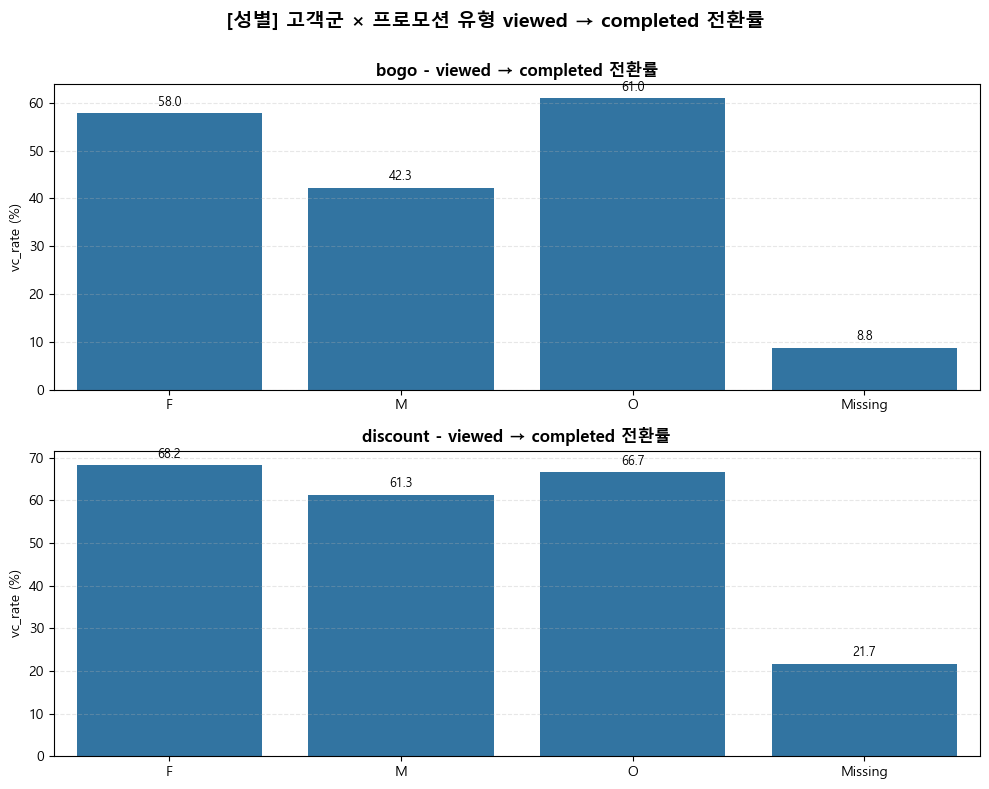

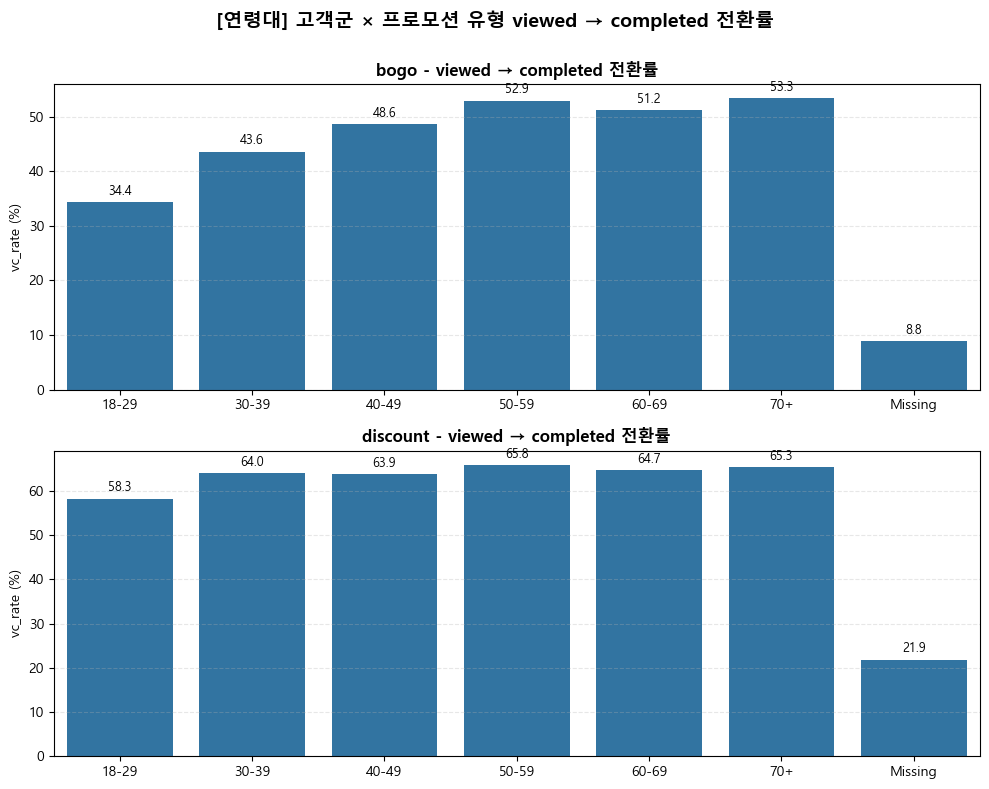

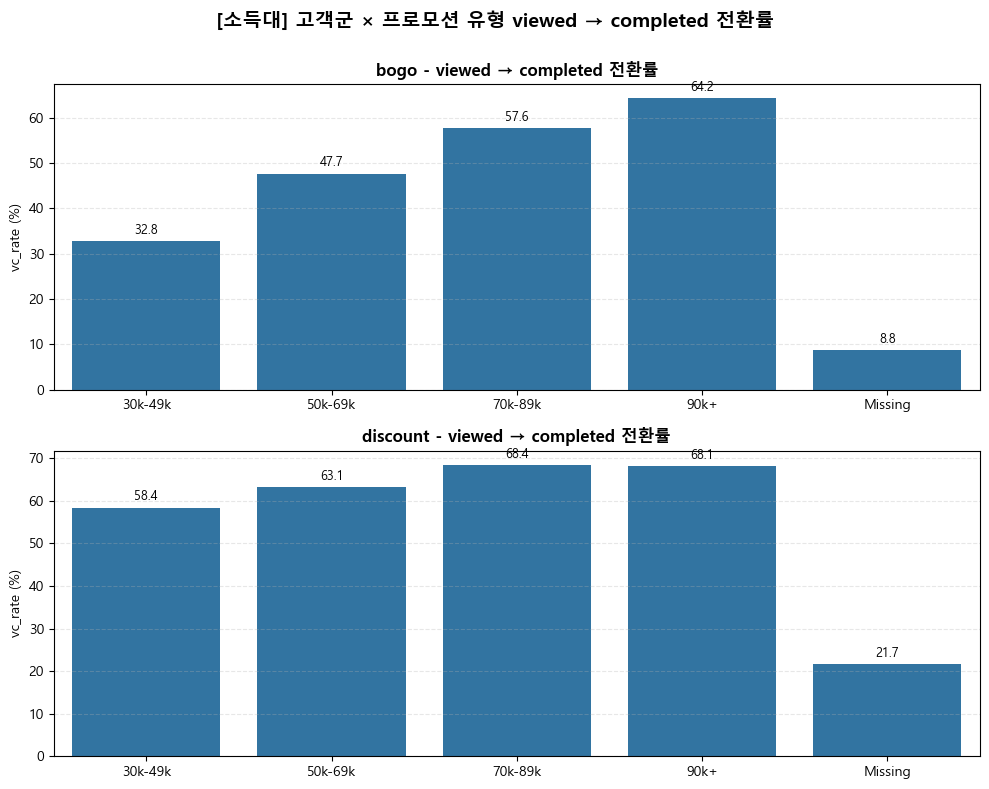

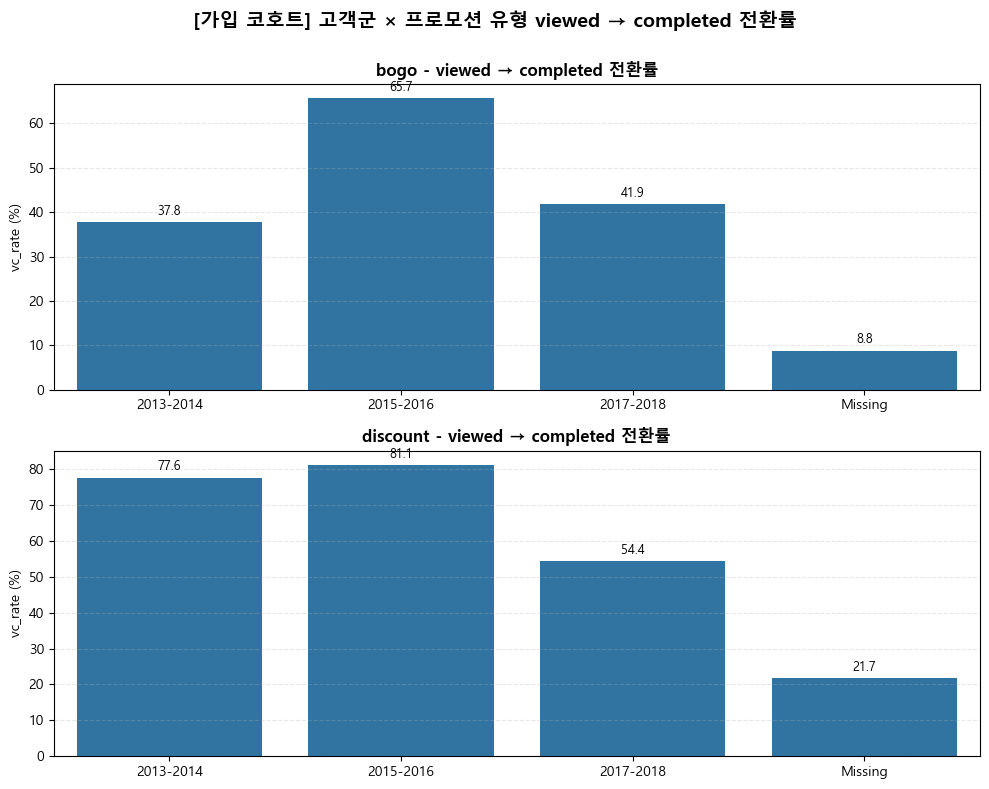

,member_cohort,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,2013-2014,bogo,1388,525,44.491429,37.824207
2,2015-2016,bogo,6837,4489,30.824683,65.657452
4,2017-2018,bogo,13640,5713,39.148608,41.884164
6,Missing,bogo,3385,297,49.979798,8.774003
1,2013-2014,discount,1162,902,61.569845,77.624785
3,2015-2016,discount,5822,4720,41.397458,81.071797
5,2017-2018,discount,11409,6203,57.293568,54.369358
7,Missing,discount,2977,647,95.480680,21.733289


In [51]:
plot_segment_offer_vc(gender_offer_vc_summary, 'gender_group', '성별')
plot_segment_offer_vc(age_offer_vc_summary, 'age_group', '연령대')
plot_segment_offer_vc(income_offer_vc_summary, 'income_group', '소득대')
plot_segment_offer_vc(cohort_offer_vc_summary, 'member_cohort', '가입 코호트')

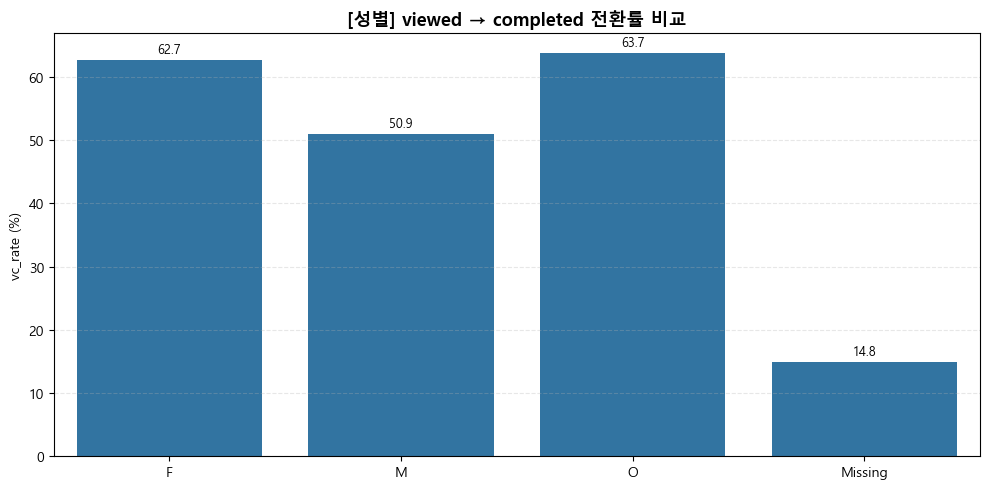

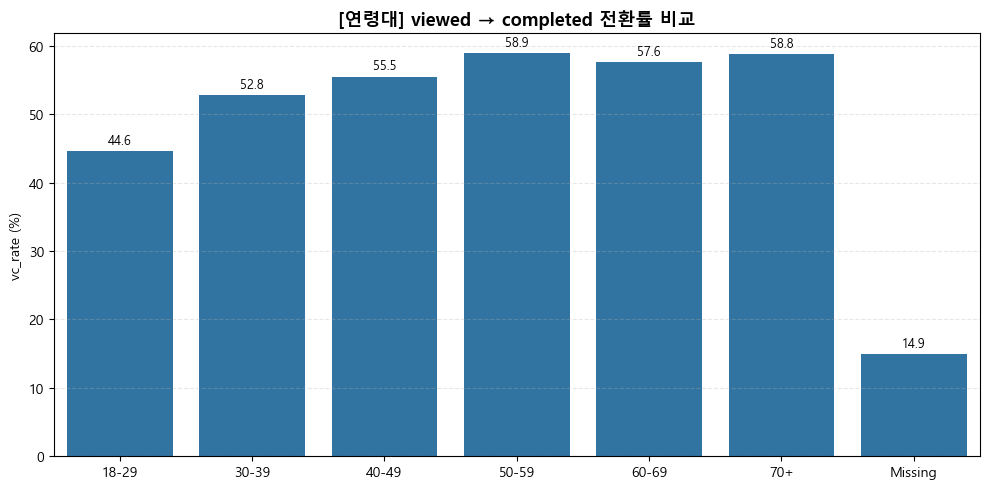

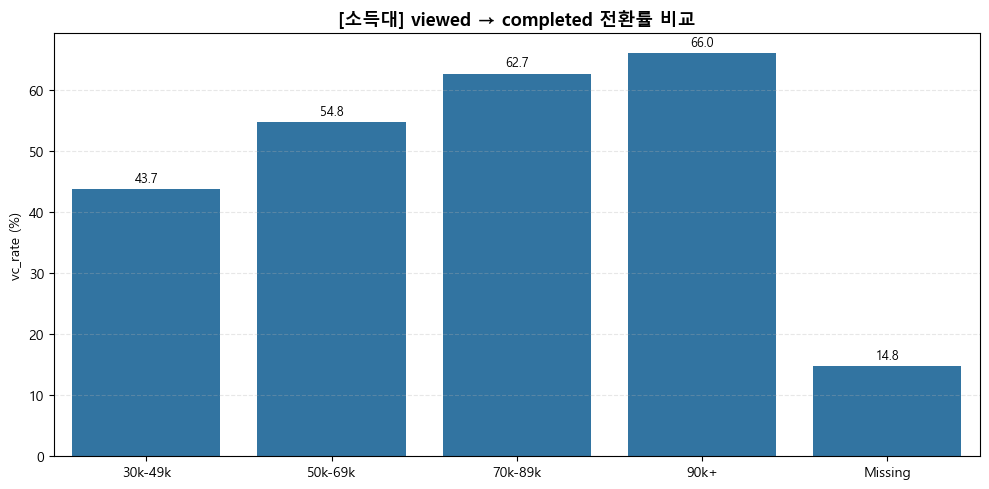

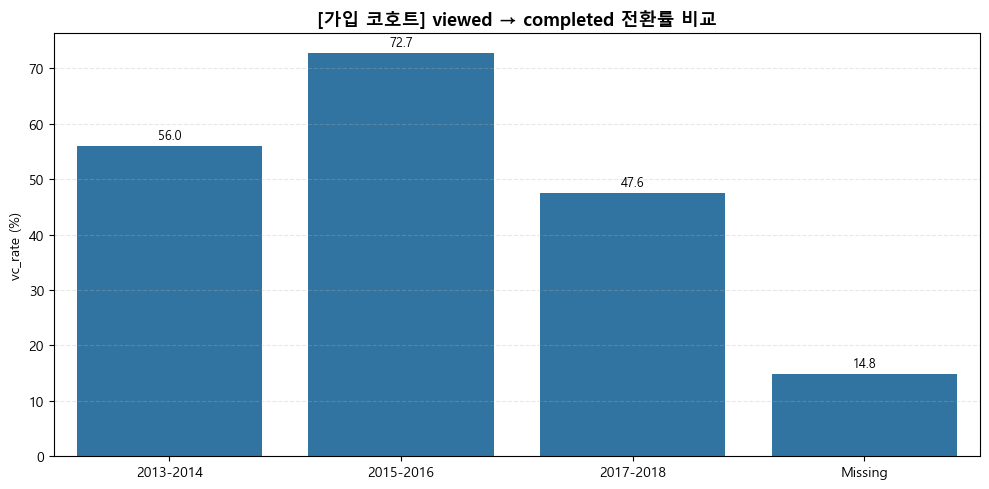

,member_cohort,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
3,2013-2014,2550,1427,55.286615,55.960784
1,2015-2016,12659,9209,36.243675,72.746662
0,2017-2018,25049,11916,48.594159,47.570761
2,Missing,6362,944,81.165254,14.838101


In [52]:
plot_segment_vc(gender_vc_summary, 'gender_group', '성별')
plot_segment_vc(age_vc_summary, 'age_group', '연령대')
plot_segment_vc(income_vc_summary, 'income_group', '소득대')
plot_segment_vc(cohort_vc_summary, 'member_cohort', '가입 코호트')#

# 3. 어떤 고객군이 오퍼를 본 뒤 완료까지 더 잘 이어지는가?
종합 보고서

## 1. 성별 기준 해석
여성(F)의 열람 후 완료율은 **51.8%**, 남성(M)은 42.0%로 나타났다.\
즉, 오퍼를 한 번 본 뒤 실제 완료까지 이어지는 것은 여성 고객군이 더 강한 편이다.

오퍼 유형별로 보면\
`bogo`에서는 여성이 **58.0%**, 남성이 42.3%였고,\
`discount`에서도 여성이 **68.2%**, 남성이 61.3%로 여성이 더 높게 나타났다.

결론적으론,\
단순 열람률 차이보다도 열람 이후 행동 전환력 자체가 여성 쪽에서 더 높다고 해석할 수 있다.\
특히 bogo처럼 실제 조건 충족이 필요한 오퍼에서 성별 차이가 더 크게 나타났다는 점이 중요하다.

디민 O 그룹은 표본 수가 적고, Missing 그룹은 결측 정보의 영향이 커서
참고용으로만 보는 것이 적절하다.

## 2. 연령대 기준 해석
18–29세는 **37.0%**로 가장 낮았고,\
30–39세는 43.4%,\
40–49세는 45.4%,\
50–59세는 48.4%,\
60–69세는 47.9%,\
70세 이상은 **48.4%**로 나타났다.

잔체적으로 보면\
연령이 높아질수록 오퍼를 본 뒤 완료까지 이어지는 비율이 높아지는 흐름이 나타난다.

20대는 오퍼를 보더라도 실제 완료 행동으로 이어지는 비율이 낮은 편이고,\
50대 이상은 상대적으로 안정적으로 완료까지 이어지는 모습이다.

오퍼 유형별로 보면\
bogo의 열람 후 완료율은\
18–29세 **34.4%**에서 시작해\
50–59세 52.9%,\
70세 이상 **53.3%**까지 올라간다.\
discount도 18–29세 58.3%, 30–39세 64.0%, 50대 이상은 65% 안팎으로 더 높다.

결론적으론,\
젊은 층은 오퍼를 보더라도 실제 완료 행동까지 이어지는 힘이 약하고,\
중장년층은 열람 이후 행동 전환이 더 안정적이라는 뜻으로 해석할 수 있다.


## 3. 소득대 기준 해석
소득대별 열람 후 완료율 차이는 매우 뚜렷하게 나타났다.
- 30k–49k: 36.1%
- 50k–69k: 44.6%
- 70k–89k: 52.1%
- 90k+: 55.1%

소득 수준이 높을수록 오퍼를 본 뒤 완료까지 이어지는 비율도 함께 높아지는 경향이 분명하게 보인다.

오퍼 유형별로 보면\
bogo는 30k–49k에서 **32.8%**였지만\
90k+에서는 **64.2%**까지 올라간다.\
거의 두 배 가까운 차이다.

discount 역시 30k–49k는 58.4%,\
70k–89k는 68.4%,\
90k+는 **68.1%**로 더 높다.

결론적으론,\
저소득 고객군은 오퍼를 본 뒤에도 실제 완료까지 이어지는 비율이 낮고,\
중·고소득 고객군은 열람 이후 행동 전환력이 훨씬 강하다고 볼 수 있다.

즉, **고소득층일수록** 실제 혜택 활용이나 완료 행동으로 더 잘 이어진다.

## 4. 가입 코호트 기준 해석
가입 시점에 따라 열람 후 완료율은 큰 차이를 보였다.\
- 2013–2014 가입 고객: 46.1%
- 2015–2016 가입 고객: 59.9%
- 2017–2018 가입 고객: 39.2%

이 중에서 가장 높은 반응을 보인 것은 2015–2016 가입 고객군이었다.\
이는 오퍼를 본 뒤 거의 10명 중 6명 수준이 완료까지 이어졌다는 뜻한다.

오퍼 유형별로 보면\
bogo에서 2015–2016 가입 고객은 65.7%,\
2017–2018 가입 고객은 **41.9%**였다.

discount에서는\
2013–2014가 77.6%,\
2015–2016이 81.1%,\
2017–2018이 **54.4%**로 나타났다.

결론적으론,\
최근 가입자라고 해서 무조건 반응이 좋은 것은 아니며,\
특정 코호트에서 오히려 더 강한 완료 전환력이 나타난다.

특히나 2015–2016 가입 고객은 bogo, discount 모두에서 높은 성과를 보이며\
**가장 강한 핵심 반응층**으로 해석할 수 있다.

## 5. 종합분석
오퍼를 본 뒤 완료까지 더 잘 이어지는 고객군은 다음과 같이 정리할 수 있다.
- 성별 기준: 여성 고객군
- 연령 기준: 50대 이상 중장년층
- 소득 기준: 70k 이상, 특히 90k+ 고소득층
- 가입 시점 기준: 2015–2016 가입 고객군

해당 고객군들이 핵심 전환층이라는 점을 확인할 수 있었다.

반대로 20대·저소득층·최근 가입 고객군은 열람 이후 완료 단계에서 왜 이탈하는지 별도로 점검할 필요가 있다.

# 4. 어떤 프로모션 유형이 열람률·완료율 측면에서 더 성과가 좋은가?
프로모션 유형(`offer_type`)별 반응 성과를 비교

- 프로모션 유형
    - bogo
    - discount
    - informational

1. received 기준 성과\
오퍼를 받은 전체 건수 중 얼마나 열람되고 완료되었는가?

2. viewed 기준 성과\
오퍼를 실제로 본 건수 중 completed까지 얼마나 이어졌는가?

주의사항
`informational`은 구조상 completed 해석이 불가능함\
되도록 완료율 비교는 `bogo`, `discount` 중심으로 보는 것이 적절

## 프로모션 유형별 전체 반응률 요약표 생성

In [53]:
# ============================================================
# 1. 프로모션 유형별 전체 반응률 요약표
# ============================================================

offer_type_summary = (
    funnel_seg
    .groupby('offer_type', dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),
        viewed_cnt=('converted_rv', 'sum'),
        completed_cnt=('converted_rc', 'sum'),
        strict_completed_cnt=('converted_rvc', 'sum')
    )
    .reset_index()
)

offer_type_summary['rv_rate'] = offer_type_summary['viewed_cnt'] / offer_type_summary['received_cnt'] * 100
offer_type_summary['rc_rate'] = offer_type_summary['completed_cnt'] / offer_type_summary['received_cnt'] * 100
offer_type_summary['rvc_rate'] = offer_type_summary['strict_completed_cnt'] / offer_type_summary['received_cnt'] * 100

offer_order = ['bogo', 'discount', 'informational']
offer_type_summary['offer_type'] = pd.Categorical(
    offer_type_summary['offer_type'],
    categories=offer_order,
    ordered=True
)
offer_type_summary = offer_type_summary.sort_values('offer_type').reset_index(drop=True)

print("=" * 70)
print("프로모션 유형별 전체 반응률 요약표")
print("=" * 70)
display(offer_type_summary)

프로모션 유형별 전체 반응률 요약표


,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,bogo,30499,25250,15501,11024,82.789600,50.824617,36.145447
1,discount,30543,21370,17651,12472,69.966932,57.790656,40.834234
2,informational,15235,9947,0,0,65.290450,0.000000,0.000000


## 프로모션 유형별 VC 요약표 생성

In [54]:
# ============================================================
# 2. 프로모션 유형별 viewed -> completed 전환률 요약표
# ============================================================

offer_type_vc_summary = (
    funnel_vc_main
    .groupby('offer_type', dropna=False)
    .agg(
        viewed_cnt=('customer_id', 'size'),
        completed_after_view_cnt=('converted_vc', 'sum'),
        avg_vc_time=('vc_time_diff', 'mean')
    )
    .reset_index()
)

offer_type_vc_summary['vc_rate'] = (
    offer_type_vc_summary['completed_after_view_cnt'] /
    offer_type_vc_summary['viewed_cnt'] * 100
)

offer_type_vc_summary['offer_type'] = pd.Categorical(
    offer_type_vc_summary['offer_type'],
    categories=['bogo', 'discount'],
    ordered=True
)
offer_type_vc_summary = offer_type_vc_summary.sort_values('offer_type').reset_index(drop=True)

print("=" * 70)
print("프로모션 유형별 viewed -> completed 전환률 요약표")
print("=" * 70)
display(offer_type_vc_summary)

프로모션 유형별 viewed -> completed 전환률 요약표


,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,bogo,25250,11024,36.305334,43.659406
1,discount,21370,12472,53.567992,58.362190


## 3. 시각화

### 시각화 함수

In [55]:
# ============================================================
# 프로모션 유형별 viewed -> completed 전환률 그래프 함수
# ============================================================

def plot_offer_type_vc(summary_df, group_title='프로모션 유형'):
    
    df_a = summary_df.copy()
    
    offer_order = ['bogo', 'discount']
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )
    df_a = df_a.sort_values('offer_type')
    
    fig, ax = plt.subplots(figsize=(8, 5))
    
    sns.barplot(
        data=df_a,
        x='offer_type',
        y='vc_rate',
        ax=ax
    )
    
    ax.set_title(f"[{group_title}] viewed → completed 전환률 비교", fontsize=13, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("vc_rate (%)")
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    for p in ax.patches:
        height = p.get_height()
        if pd.notna(height):
            ax.annotate(
                f"{height:.1f}",
                (p.get_x() + p.get_width() / 2, height),
                ha='center',
                va='bottom',
                fontsize=9,
                xytext=(0, 3),
                textcoords='offset points'
            )
    
    plt.tight_layout()
    plt.show()
    
    return df_a

In [56]:
# ============================================================
# 프로모션 유형별 전체 반응률 그래프 함수
# ============================================================

def plot_offer_type(summary_df, group_title='프로모션 유형'):
    
    df_a = summary_df.copy()
    
    offer_order = ['bogo', 'discount', 'informational']
    df_a['offer_type'] = pd.Categorical(
        df_a['offer_type'],
        categories=offer_order,
        ordered=True
    )
    df_a = df_a.sort_values('offer_type')
    
    metric_cols = ['rv_rate', 'rc_rate', 'rvc_rate']
    metric_names = ['열람률', '완료율', '엄격 완료율']
    
    n_rows = len(metric_cols)
    fig, axes = plt.subplots(n_rows, 1, figsize=(8, n_rows * 4))
    
    if n_rows == 1:
        axes = [axes]
    
    for i, (metric_col, metric_name) in enumerate(zip(metric_cols, metric_names)):
        sns.barplot(
            data=df_a,
            x='offer_type',
            y=metric_col,
            ax=axes[i]
        )
        
        axes[i].set_title(f"{metric_name} 비교", fontsize=12, fontweight='bold')
        axes[i].set_xlabel("")
        axes[i].set_ylabel("반응률(%)")
        axes[i].grid(axis='y', linestyle='--', alpha=0.3)
        
        for p in axes[i].patches:
            height = p.get_height()
            if pd.notna(height):
                axes[i].annotate(
                    f"{height:.1f}",
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    xytext=(0, 3),
                    textcoords='offset points'
                )
    
    fig.suptitle(f"[{group_title}] 전체 반응률 비교", fontsize=15, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()
    
    return df_a

### 시각화

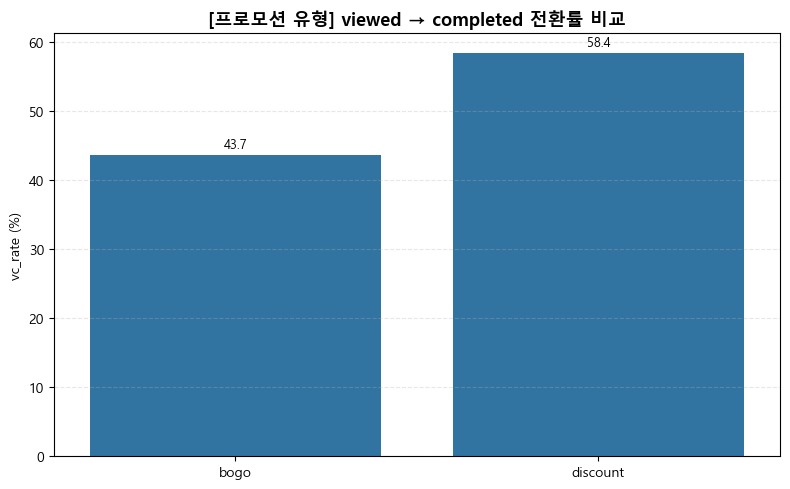

,offer_type,viewed_cnt,completed_after_view_cnt,avg_vc_time,vc_rate
0,bogo,25250,11024,36.305334,43.659406
1,discount,21370,12472,53.567992,58.362190


In [57]:
plot_offer_type_vc(offer_type_vc_summary, '프로모션 유형')

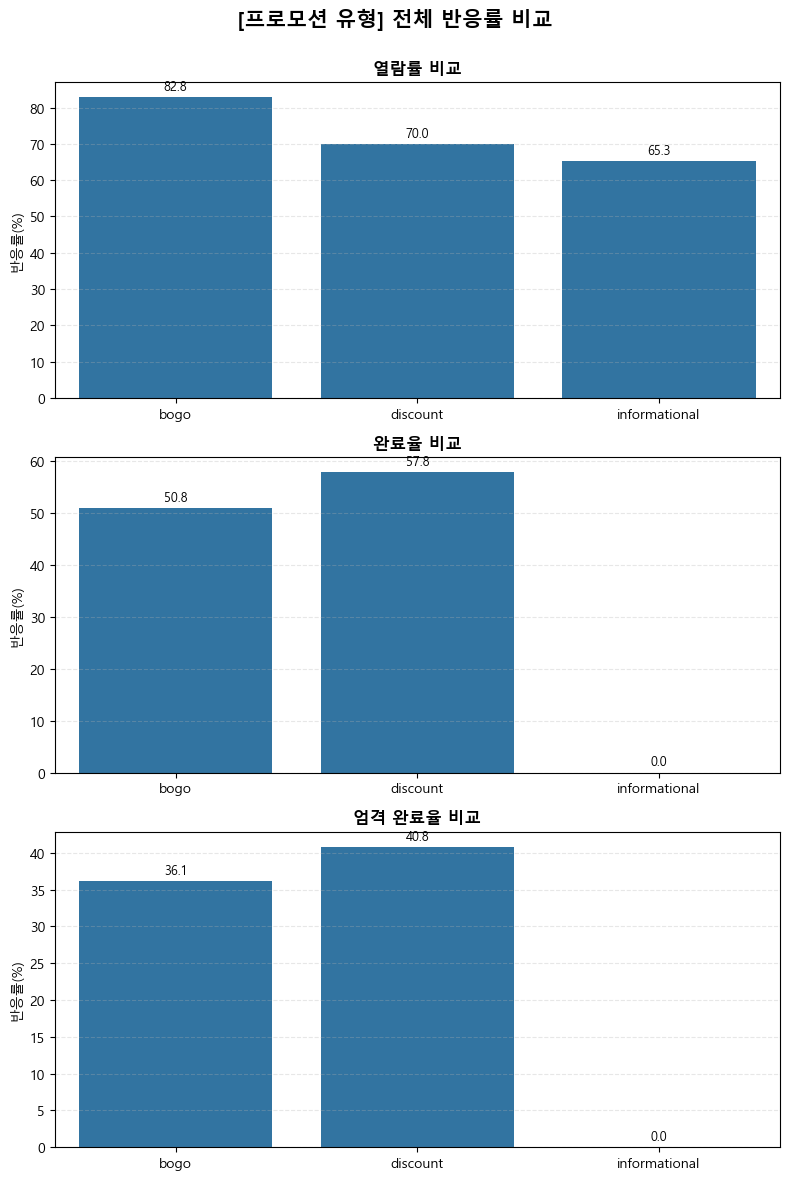

,offer_type,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,bogo,30499,25250,15501,11024,82.789600,50.824617,36.145447
1,discount,30543,21370,17651,12472,69.966932,57.790656,40.834234
2,informational,15235,9947,0,0,65.290450,0.000000,0.000000


In [58]:
plot_offer_type(offer_type_summary, '프로모션 유형')

# 4. 어떤 프로모션 유형이 열람률·완료율 측면에서 더 성과가 좋은가?
종합 보고서

## 1. 전체 수치 해석
- bogo
    - 열람률: 82.8%
    - 완료율: 50.8%
    - 정상 퍼널 완료율: 36.1%
- discount
    - 열람률: 70.0%
    - 완료율: 57.8%
    - 정상 퍼널 완료율: 40.8%
- informational
    - 열람률: 65.3%
    - 완료율: 0.0%
    - 정상 퍼널 완료율: 0.0%

### bogo
bogo는 열람률이 **82.8%**로 가장 높았다.\
이 수치는 고객들이 세 가지 유형 중에서 bogo 오퍼를 가장 자주 확인했다는 뜻이다.\
즉, 고객 반응의 첫 단계인 '보게 만드는 힘'에서는 가장 강한 유형이라고 볼 수 있다.\
다만 완료율은 50.8%, 정상 퍼널 완료율은 36.1%로 완료 단계에서는 discount보다 다소 낮았다.

따라서 bogo는 고객 주목을 끌고 반응을 시작하게 만드는 데 강하지만,\
최종 완료까지 안정적으로 이어지는 힘은 상대적으로 조금 약한 편이다.

### discount
discount는 열람률이 **70.0%**로 bogo보다 낮았다.\
하지만 완료율은 57.8%, 정상 퍼널 완료율은 **40.8%**로 가장 높았다.\
즉, 이 유형은 오퍼를 확인한 고객이 실제 행동까지 이어질 가능성이 가장 높은 유형이었다.

보는 비율 자체는 bogo보다 낮지만, 실제로 사용할 가능성은 더 높은 유형이라 해석할 수 있다.

### informational
informational은 열람률이 **65.3%**로 나타났고, 완료율과 정상 퍼널 완료율은 모두 **0%**였다.\
이 유형은 애초에 완료를 목표로 하는 프로모션이 아니라, 고객에게 정보를 전달하거나 노출하는 성격이 강하다.\
따라서 얼마나 잘 열람되었는가만 중심으로 해석하는 것이 적절하다.

## 2. 종합해석
프로모션 유형별 성과는 다음처럼 정리할 수 있다.
- 열람률 기준 최고 성과: bogo
- 완료율 기준 최고 성과: discount
- 정상 퍼널 완료율 기준 최고 성과: discount
- 정보 전달용 해석 대상: informational

즉, bogo는 고객의 관심을 끌고 오퍼를 보게 만드는 데 가장 강했고,\
discount는 실제 완료 행동까지 이어지게 만드는 데 가장 강했다.\
따라서 프로모션 목적에 따라 유형 선택이 달라져야 한다고 해석할 수 있다.

# 번외: 유형별 세부 오퍼 비교

In [59]:
# ============================================================
# offer_id 기준 세부 비교 요약표
# ============================================================
offer_detail_summary = (
    funnel_seg
    .groupby(['offer_type', 'offer_id'], dropna=False)
    .agg(
        received_cnt=('customer_id', 'size'),
        viewed_cnt=('converted_rv', 'sum'),
        completed_cnt=('converted_rc', 'sum'),
        strict_completed_cnt=('converted_rvc', 'sum')
    )
    .reset_index()
)

offer_detail_summary['rv_rate'] = offer_detail_summary['viewed_cnt'] / offer_detail_summary['received_cnt'] * 100
offer_detail_summary['rc_rate'] = offer_detail_summary['completed_cnt'] / offer_detail_summary['received_cnt'] * 100
offer_detail_summary['rvc_rate'] = offer_detail_summary['strict_completed_cnt'] / offer_detail_summary['received_cnt'] * 100

offer_detail_summary['offer_type'] = pd.Categorical(
    offer_detail_summary['offer_type'],
    categories=offer_order,
    ordered=True
)

offer_detail_summary = offer_detail_summary.sort_values(
    ['offer_type', 'rv_rate'],
    ascending=[True, False]
).reset_index(drop=True)

print("=" * 70)
print("offer_id 기준 세부 비교 요약표")
print("=" * 70)
display(offer_detail_summary)

offer_id 기준 세부 비교 요약표


,offer_type,offer_id,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,7593,7235,3301,2751,95.285131,43.474253,36.230739
1,bogo,f19421c1d4aa40978ebb69ca19b0e20d,7571,7208,4262,3536,95.205389,56.293752,46.704530
2,bogo,ae264e3637204a6fb9bb56bc8210ddfd,7658,6679,3635,2613,87.215983,47.466701,34.121180
3,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,7677,4128,4303,2124,53.771004,56.050541,27.667057
4,discount,fafdcd668e3743c1bb461111dcafc2a4,7597,7327,5251,4635,96.445966,69.119389,61.010925
5,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,7646,7330,5108,4377,95.867120,66.806173,57.245619
6,discount,2906b810c7d4411798c6938adc9daaa5,7632,4061,3958,2128,53.210168,51.860587,27.882600
7,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,7668,2652,3334,1332,34.585290,43.479395,17.370892
8,informational,5a8bc65990b245e5a138643cd4eb9837,7618,6149,0,0,80.716724,0.000000,0.000000
9,informational,3f207df678b143eea3cee63160fa8bed,7617,3798,0,0,49.862150,0.000000,0.000000


In [60]:
# ============================================================
# 유형별 열람률, 완료율 상위 오퍼
# ============================================================

# 유형별 열람률 상위 오퍼
top_offer_rv = (
    offer_detail_summary
    .sort_values(['offer_type', 'rv_rate'], ascending=[True, False])
    .groupby('offer_type')
    .head(3)
    .reset_index(drop=True)
)

# 유형별 완료율 상위 오퍼
top_offer_rc = (
    offer_detail_summary
    .sort_values(['offer_type', 'rc_rate'], ascending=[True, False])
    .groupby('offer_type')
    .head(3)
    .reset_index(drop=True)
)

print("=" * 70)
print("유형별 열람률 상위 오퍼")
print("=" * 70)
display(top_offer_rv)

print("=" * 70)
print("유형별 완료율 상위 오퍼")
print("=" * 70)
display(top_offer_rc)

유형별 열람률 상위 오퍼


,offer_type,offer_id,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,7593,7235,3301,2751,95.285131,43.474253,36.230739
1,bogo,f19421c1d4aa40978ebb69ca19b0e20d,7571,7208,4262,3536,95.205389,56.293752,46.704530
2,bogo,ae264e3637204a6fb9bb56bc8210ddfd,7658,6679,3635,2613,87.215983,47.466701,34.121180
3,discount,fafdcd668e3743c1bb461111dcafc2a4,7597,7327,5251,4635,96.445966,69.119389,61.010925
4,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,7646,7330,5108,4377,95.867120,66.806173,57.245619
5,discount,2906b810c7d4411798c6938adc9daaa5,7632,4061,3958,2128,53.210168,51.860587,27.882600
6,informational,5a8bc65990b245e5a138643cd4eb9837,7618,6149,0,0,80.716724,0.000000,0.000000
7,informational,3f207df678b143eea3cee63160fa8bed,7617,3798,0,0,49.862150,0.000000,0.000000


유형별 완료율 상위 오퍼


,offer_type,offer_id,received_cnt,viewed_cnt,completed_cnt,strict_completed_cnt,rv_rate,rc_rate,rvc_rate
0,bogo,f19421c1d4aa40978ebb69ca19b0e20d,7571,7208,4262,3536,95.205389,56.293752,46.704530
1,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,7677,4128,4303,2124,53.771004,56.050541,27.667057
2,bogo,ae264e3637204a6fb9bb56bc8210ddfd,7658,6679,3635,2613,87.215983,47.466701,34.121180
3,discount,fafdcd668e3743c1bb461111dcafc2a4,7597,7327,5251,4635,96.445966,69.119389,61.010925
4,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,7646,7330,5108,4377,95.867120,66.806173,57.245619
5,discount,2906b810c7d4411798c6938adc9daaa5,7632,4061,3958,2128,53.210168,51.860587,27.882600
6,informational,5a8bc65990b245e5a138643cd4eb9837,7618,6149,0,0,80.716724,0.000000,0.000000
7,informational,3f207df678b143eea3cee63160fa8bed,7617,3798,0,0,49.862150,0.000000,0.000000


# 번외: 유형별 세부 오퍼 비교
종합분석

전체적으로 보면, 세부 오퍼 수준에서는 다음과 같은 패턴이 확인된다.

- bogo에서는\
보상 5 / 난이도 5 / 5일 / 4채널 조합 오퍼가 가장 균형 잡힌 성과를 보였다.

- discount에서는\
보상 2 / 난이도 10 / 10일 / 4채널 조합 오퍼가 가장 높은 성과를 보였다.

- informational에서는\
3일 / email+mobile+social 조합 오퍼가 더 높은 열람률을 보였다.